# Decision Trees and Forests

In this session, you will learn about decision trees and random forests using various datasets. We will also dive into cross-validation techniques to robustly evaluate your model's performance. 






You will cover the following topics:

1. **Loading a Dataset**  

2. **Implementing a Decision Tree using Scikit-Learn**  

3. **Ensemble Methods: Bagging and Random Forest Classifiers**  

4. **Cross-Validation**  

5. **Advanced Section: Implementing a Decision Tree from Scratch**  



In [58]:
# Import needed libraries
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.model_selection import cross_val_score, cross_validate


## 1. Loading and Inspecting a Dataset

Scikit-learn comes with several standard **toy datasets** that are useful for practicing machine learning techniques. These datasets are built-in, so there's no need to download any external files.





We'll use the **[Iris dataset](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_iris.html)**, 150 samples across 3 species, 4 numerical features, loaded directly from scikit-learn.

<details>
<summary>Dataset details</summary>

**Features** (all in cm): `sepal length`, `sepal width`, `petal length`, `petal width`

**Target classes:** `0` = *Setosa*, `1` = *Versicolor*, `2` = *Virginica* — 50 samples each

> See all scikit-learn toy datasets: [documentation](https://scikit-learn.org/stable/datasets/toy_dataset.html#toy-datasets)
</details>

We load it and store it as a DataFrame `df` used throughout this notebook.


In [59]:
raw_data = load_iris()
df = pd.DataFrame(raw_data.data, columns=raw_data.feature_names)
df['target'] = raw_data.target

- details on the size and variables in this dataframe

In [60]:
df.info() 

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


- print the first few rows of this data

In [61]:
df.head() 

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


### 🔍 Example : Splitting the Dataset: Training and Testing Sets

For this example, we will use Scikit-learn's `train_test_split` function to split the Iris dataset into two parts:
- **Training Set (70%)**: Used to train the machine learning models.
- **Test Set (30%)**: Used to evaluate the performance of the trained models.

> **Note:** We are not using a separate validation/development set. 
In real-world projects it's recommended to create one to fine-tune your models without influencing the final test results.


In [62]:

X_train, X_test, y_train, y_test = train_test_split(df[raw_data.feature_names], 
                                                    df['target'], 
                                                    test_size=0.3, 
                                                    random_state=0)

- We can check that the resulting dimensionality of these subsets are correct:

In [63]:
# The number of rows in the training features and training labels are equal
print("Train: ", X_train.shape[0], y_train.shape[0])

# The number of rows in the testing features and testing labels are equal
print("Test:  ", X_test.shape[0], y_test.shape[0])

# The number of rows in the training plus testing is equal to the rows in the full dataset
print("All rows accounted for:", X_train.shape[0] + X_test.shape[0], df.shape[0])


Train:  105 105
Test:   45 45
All rows accounted for: 150 150


In [64]:
# The number of feature columns in the training and test set matches, 
# and contains one fewer column than the full dataset:
print(X_train.shape[1], X_test.shape[1], df.shape[1])

4 4 5


In [65]:
# The training and testing labels don't have columns, they are only one dimension:
print(y_train.ndim, y_test.ndim)

1 1


---

### **💡 Thought question**: 

To apply a decision tree to this data, do we need to <b> standardize </b> these features? Why or why not? What would need to change to change your answer to this question?

<details>

<summary> <b> Click me for answer </b> </summary>

For a decision tree, features do not need to be standardized. For other models, for example linear regression, the model may assume features are standardized.

</details>

---

## 2. Implementing a Decision Tree using the Scikit-Learn Library

When training a decision tree, we recursively partition the data by selecting the feature and threshold that maximally reduce impurity (e.g. Gini or entropy) at each node. 




> **Split Explorer**
>
> All 150 Iris samples plotted along one feature axis (selectable between petal length, petal width, and sepal length). The y axis is jittered randomly and carries no meaning. Colours represent the three species (pink = Setosa, teal = Versicolor, purple = Virginica). The yellow dashed line is the candidate split threshold. Drag it and watch the Gini or Entropy impurity update on each side, along with the weighted total the algorithm tries to minimise.
>
> *Drag the line to the point of lowest weighted impurity. Which feature produces the cleanest first split?*

In [66]:
from IPython.display import HTML
HTML('<div style="overflow:hidden; height:580px;"><iframe src="data:text/html;base64,PCFET0NUWVBFIGh0bWw+CjxodG1sIGxhbmc9ImVuIj4KPGhlYWQ+CjxtZXRhIGNoYXJzZXQ9IlVURi04Ij4KPG1ldGEgbmFtZT0idmlld3BvcnQiIGNvbnRlbnQ9IndpZHRoPWRldmljZS13aWR0aCwgaW5pdGlhbC1zY2FsZT0xLjAiPgo8dGl0bGU+U3BsaXQgRXhwbG9yZXI8L3RpdGxlPgo8c3R5bGU+CiAgQGltcG9ydCB1cmwoJ2h0dHBzOi8vZm9udHMuZ29vZ2xlYXBpcy5jb20vY3NzMj9mYW1pbHk9RE0rU2Fuczp3Z2h0QDQwMDs1MDA7NzAwJmZhbWlseT1KZXRCcmFpbnMrTW9ubzp3Z2h0QDQwMDs2MDAmZGlzcGxheT1zd2FwJyk7CiAgKnttYXJnaW46MDtwYWRkaW5nOjA7Ym94LXNpemluZzpib3JkZXItYm94fQogIGJvZHl7Zm9udC1mYW1pbHk6J0RNIFNhbnMnLHNhbnMtc2VyaWY7YmFja2dyb3VuZDojMGYxMTE3O2NvbG9yOiNkNGQ0ZTA7ZGlzcGxheTpmbGV4O2ZsZXgtZGlyZWN0aW9uOmNvbHVtbjthbGlnbi1pdGVtczpjZW50ZXI7cGFkZGluZzoyNHB4fQogIC5oZWFkZXJ7d2lkdGg6MTAwJTttYXgtd2lkdGg6ODIwcHg7bWFyZ2luLWJvdHRvbToxNnB4fQogIGgye2ZvbnQtc2l6ZToxLjNyZW07Zm9udC13ZWlnaHQ6NzAwO2NvbG9yOiNmZmY7bWFyZ2luLWJvdHRvbTo0cHh9CiAgLmNvbnRyb2xze2Rpc3BsYXk6ZmxleDtnYXA6NHB4O2FsaWduLWl0ZW1zOmNlbnRlcjtiYWNrZ3JvdW5kOiMxODFhMjQ7Ym9yZGVyLXJhZGl1czo4cHg7cGFkZGluZzo0cHg7Ym9yZGVyOjFweCBzb2xpZCAjMjUyODM4O3dpZHRoOmZpdC1jb250ZW50O21hcmdpbi1ib3R0b206MTRweH0KICAuY3RybC1sYWJlbHtmb250LXNpemU6MC43MnJlbTtjb2xvcjojNzA4MGEwO3BhZGRpbmc6MCA4cHg7dGV4dC10cmFuc2Zvcm06dXBwZXJjYXNlO2xldHRlci1zcGFjaW5nOi41cHh9CiAgLmJ0bntmb250LWZhbWlseTonRE0gU2Fucycsc2Fucy1zZXJpZjtmb250LXNpemU6LjhyZW07cGFkZGluZzo2cHggMTNweDtib3JkZXItcmFkaXVzOjZweDtib3JkZXI6bm9uZTtiYWNrZ3JvdW5kOnRyYW5zcGFyZW50O2NvbG9yOiM4ODk4Yjg7Y3Vyc29yOnBvaW50ZXI7dHJhbnNpdGlvbjouMTVzfQogIC5idG46aG92ZXJ7Y29sb3I6I2MwYzhlMH0KICAuYnRuLmFjdGl2ZXtiYWNrZ3JvdW5kOiMyZDMwNjA7Y29sb3I6I2ZmZn0KICAudml6LXdyYXB7cG9zaXRpb246cmVsYXRpdmU7YmFja2dyb3VuZDojMTgxYTI0O2JvcmRlci1yYWRpdXM6MTRweDtwYWRkaW5nOjIwcHg7Ym9yZGVyOjFweCBzb2xpZCAjMjUyODM4O21heC13aWR0aDo4MjBweDt3aWR0aDoxMDAlfQogIGNhbnZhc3tkaXNwbGF5OmJsb2NrO2JvcmRlci1yYWRpdXM6NnB4O2N1cnNvcjpldy1yZXNpemU7d2lkdGg6MTAwJX0KICAub3ZlcmxheXtwb3NpdGlvbjphYnNvbHV0ZTtwb2ludGVyLWV2ZW50czpub25lfQogIC5tZXRyaWMtcGlsbHtwb3NpdGlvbjphYnNvbHV0ZTtiYWNrZ3JvdW5kOnJnYmEoMTUsMTcsMjMsLjg4KTtib3JkZXI6MXB4IHNvbGlkICMyYTJkM2E7Ym9yZGVyLXJhZGl1czo4cHg7cGFkZGluZzo4cHggMTRweDtmb250LWZhbWlseTonSmV0QnJhaW5zIE1vbm8nLG1vbm9zcGFjZTtiYWNrZHJvcC1maWx0ZXI6Ymx1cig0cHgpfQogIC5tZXRyaWMtcGlsbCAubGFiZWx7Zm9udC1zaXplOi42NXJlbTt0ZXh0LXRyYW5zZm9ybTp1cHBlcmNhc2U7bGV0dGVyLXNwYWNpbmc6LjVweDttYXJnaW4tYm90dG9tOjJweH0KICAubWV0cmljLXBpbGwgLnZhbHtmb250LXNpemU6MS4xcmVtO2ZvbnQtd2VpZ2h0OjYwMH0KICAucGlsbC1sZWZ0e3RvcDoxNnB4O2xlZnQ6MTZweH0KICAucGlsbC1yaWdodHt0b3A6MTZweDtyaWdodDoxNnB4fQogIC5waWxsLWNlbnRlcntib3R0b206ODBweDtsZWZ0OjE2cHg7dGV4dC1hbGlnbjpsZWZ0fQogIC5sZWdlbmR7ZGlzcGxheTpmbGV4O2dhcDoxNnB4O2p1c3RpZnktY29udGVudDpjZW50ZXI7bWFyZ2luLXRvcDoxMHB4fQogIC5sZWdlbmQtaXRlbXtkaXNwbGF5OmZsZXg7YWxpZ24taXRlbXM6Y2VudGVyO2dhcDo1cHg7Zm9udC1zaXplOi43OHJlbTtjb2xvcjojOWFhfQogIC5sZWdlbmQtZG90e3dpZHRoOjhweDtoZWlnaHQ6OHB4O2JvcmRlci1yYWRpdXM6NTAlfQogIC5mb3JtdWxhLWJhcnt0ZXh0LWFsaWduOmNlbnRlcjttYXJnaW4tdG9wOjhweDtmb250LWZhbWlseTonSmV0QnJhaW5zIE1vbm8nLG1vbm9zcGFjZTtmb250LXNpemU6Ljc4cmVtO2NvbG9yOiM4ODk4Yjg7YmFja2dyb3VuZDojMTIxNDFlO2JvcmRlci1yYWRpdXM6NnB4O3BhZGRpbmc6NnB4IDEycHh9CiAgLmRyYWctaGludHtwb3NpdGlvbjphYnNvbHV0ZTtib3R0b206OTRweDtsZWZ0OjUwJTt0cmFuc2Zvcm06dHJhbnNsYXRlWCgtNTAlKTtmb250LXNpemU6Ljc4cmVtO2NvbG9yOiNmZmQ5NjY7b3BhY2l0eTowO2FuaW1hdGlvbjpmYWRlSGludCAzcyBlYXNlLWluLW91dCBmb3J3YXJkcztwb2ludGVyLWV2ZW50czpub25lfQogIEBrZXlmcmFtZXMgZmFkZUhpbnR7MCV7b3BhY2l0eTowfTE1JXtvcGFjaXR5OjF9ODUle29wYWNpdHk6MX0xMDAle29wYWNpdHk6MH19Cjwvc3R5bGU+CjwvaGVhZD4KPGJvZHk+CjxkaXYgY2xhc3M9ImhlYWRlciI+CiAgPGgyPlNwbGl0IEV4cGxvcmVyPC9oMj4KICA8ZGl2IHN0eWxlPSJkaXNwbGF5OmZsZXg7Z2FwOjEycHg7ZmxleC13cmFwOndyYXAiPgogICAgPGRpdiBjbGFzcz0iY29udHJvbHMiPgogICAgICA8c3BhbiBjbGFzcz0iY3RybC1sYWJlbCI+RmVhdHVyZTwvc3Bhbj4KICAgICAgPGJ1dHRvbiBjbGFzcz0iYnRuIGFjdGl2ZSIgZGF0YS1mZWF0dXJlPSJwZXRhbF9sZW5ndGgiPlBldGFsIExlbmd0aDwvYnV0dG9uPgogICAgICA8YnV0dG9uIGNsYXNzPSJidG4iIGRhdGEtZmVhdHVyZT0icGV0YWxfd2lkdGgiPlBldGFsIFdpZHRoPC9idXR0b24+CiAgICAgIDxidXR0b24gY2xhc3M9ImJ0biIgZGF0YS1mZWF0dXJlPSJzZXBhbF9sZW5ndGgiPlNlcGFsIExlbmd0aDwvYnV0dG9uPgogICAgPC9kaXY+CiAgICA8ZGl2IGNsYXNzPSJjb250cm9scyI+CiAgICAgIDxzcGFuIGNsYXNzPSJjdHJsLWxhYmVsIj5NZXRyaWM8L3NwYW4+CiAgICAgIDxidXR0b24gY2xhc3M9ImJ0biBhY3RpdmUiIGRhdGEtbWV0cmljPSJnaW5pIj5HaW5pPC9idXR0b24+CiAgICAgIDxidXR0b24gY2xhc3M9ImJ0biIgZGF0YS1tZXRyaWM9ImVudHJvcHkiPkVudHJvcHk8L2J1dHRvbj4KICAgIDwvZGl2PgogIDwvZGl2Pgo8L2Rpdj4KCjxkaXYgY2xhc3M9InZpei13cmFwIj4KICA8Y2FudmFzIGlkPSJjIiBoZWlnaHQ9IjQwMCI+PC9jYW52YXM+CiAgPGRpdiBjbGFzcz0ibWV0cmljLXBpbGwgcGlsbC1sZWZ0Ij4KICAgIDxkaXYgY2xhc3M9ImxhYmVsIiBzdHlsZT0iY29sb3I6IzRlY2RjNCI+TGVmdCAo4omkIHRocmVzaG9sZCk8L2Rpdj4KICAgIDxkaXYgY2xhc3M9InZhbCIgc3R5bGU9ImNvbG9yOiM0ZWNkYzQiPjxzcGFuIGlkPSJsZWZ0TiI+MDwvc3Bhbj4gc2FtcGxlcyDCtyA8c3BhbiBpZD0ibGVmdEltcCI+MC4wMDA8L3NwYW4+PC9kaXY+CiAgPC9kaXY+CiAgPGRpdiBjbGFzcz0ibWV0cmljLXBpbGwgcGlsbC1yaWdodCI+CiAgICA8ZGl2IGNsYXNzPSJsYWJlbCIgc3R5bGU9ImNvbG9yOiM2YTZkZmEiPlJpZ2h0ICgmZ3Q7IHRocmVzaG9sZCk8L2Rpdj4KICAgIDxkaXYgY2xhc3M9InZhbCIgc3R5bGU9ImNvbG9yOiM2YTZkZmEiPjxzcGFuIGlkPSJyaWdodE4iPjA8L3NwYW4+IHNhbXBsZXMgwrcgPHNwYW4gaWQ9InJpZ2h0SW1wIj4wLjAwMDwvc3Bhbj48L2Rpdj4KICA8L2Rpdj4KICA8ZGl2IGNsYXNzPSJtZXRyaWMtcGlsbCBwaWxsLWNlbnRlciI+CiAgICA8ZGl2IGNsYXNzPSJsYWJlbCIgc3R5bGU9ImNvbG9yOiNmZmQ5NjYiPldlaWdodGVkIGltcHVyaXR5PC9kaXY+CiAgICA8ZGl2IGNsYXNzPSJ2YWwiIHN0eWxlPSJjb2xvcjojZmZkOTY2IiBpZD0idG90YWxJbXAiPjAuMDAwPC9kaXY+CiAgPC9kaXY+CiAgPGRpdiBjbGFzcz0iZHJhZy1oaW50IiBpZD0iZHJhZ0hpbnQiPuKftyBkcmFnIHRoZSB5ZWxsb3cgbGluZTwvZGl2PgogIDxkaXYgY2xhc3M9ImxlZ2VuZCI+CiAgICA8ZGl2IGNsYXNzPSJsZWdlbmQtaXRlbSI+PGRpdiBjbGFzcz0ibGVnZW5kLWRvdCIgc3R5bGU9ImJhY2tncm91bmQ6I2ZmNmI4YSI+PC9kaXY+U2V0b3NhPC9kaXY+CiAgICA8ZGl2IGNsYXNzPSJsZWdlbmQtaXRlbSI+PGRpdiBjbGFzcz0ibGVnZW5kLWRvdCIgc3R5bGU9ImJhY2tncm91bmQ6IzRlY2RjNCI+PC9kaXY+VmVyc2ljb2xvcjwvZGl2PgogICAgPGRpdiBjbGFzcz0ibGVnZW5kLWl0ZW0iPjxkaXYgY2xhc3M9ImxlZ2VuZC1kb3QiIHN0eWxlPSJiYWNrZ3JvdW5kOiM2YTZkZmEiPjwvZGl2PlZpcmdpbmljYTwvZGl2PgogIDwvZGl2PgogIDxkaXYgY2xhc3M9ImZvcm11bGEtYmFyIiBpZD0iZm9ybXVsYSI+PC9kaXY+CjwvZGl2PgoKPHNjcmlwdD4KY29uc3QgaXJpcz1bCls1LjEsMy41LDEuNCwuMiwwXSxbNC45LDMsMS40LC4yLDBdLFs0LjcsMy4yLDEuMywuMiwwXSxbNC42LDMuMSwxLjUsLjIsMF0sWzUsMy42LDEuNCwuMiwwXSwKWzUuNCwzLjksMS43LC40LDBdLFs0LjYsMy40LDEuNCwuMywwXSxbNSwzLjQsMS41LC4yLDBdLFs0LjQsMi45LDEuNCwuMiwwXSxbNC45LDMuMSwxLjUsLjEsMF0sCls1LjQsMy43LDEuNSwuMiwwXSxbNC44LDMuNCwxLjYsLjIsMF0sWzQuOCwzLDEuNCwuMSwwXSxbNC4zLDMsMS4xLC4xLDBdLFs1LjgsNCwxLjIsLjIsMF0sCls1LjcsNC40LDEuNSwuNCwwXSxbNS40LDMuOSwxLjMsLjQsMF0sWzUuMSwzLjUsMS40LC4zLDBdLFs1LjcsMy44LDEuNywuMywwXSxbNS4xLDMuOCwxLjUsLjMsMF0sCls1LjQsMy40LDEuNywuMiwwXSxbNS4xLDMuNywxLjUsLjQsMF0sWzQuNiwzLjYsMSwuMiwwXSxbNS4xLDMuMywxLjcsLjUsMF0sWzQuOCwzLjQsMS45LC4yLDBdLApbNSwzLDEuNiwuMiwwXSxbNSwzLjQsMS42LC40LDBdLFs1LjIsMy41LDEuNSwuMiwwXSxbNS4yLDMuNCwxLjQsLjIsMF0sWzQuNywzLjIsMS42LC4yLDBdLApbNC44LDMuMSwxLjYsLjIsMF0sWzUuNCwzLjQsMS41LC40LDBdLFs1LjIsNC4xLDEuNSwuMSwwXSxbNS41LDQuMiwxLjQsLjIsMF0sWzQuOSwzLjEsMS41LC4yLDBdLApbNSwzLjIsMS4yLC4yLDBdLFs1LjUsMy41LDEuMywuMiwwXSxbNC45LDMuNiwxLjQsLjEsMF0sWzQuNCwzLDEuMywuMiwwXSxbNS4xLDMuNCwxLjUsLjIsMF0sCls1LDMuNSwxLjMsLjMsMF0sWzQuNSwyLjMsMS4zLC4zLDBdLFs0LjQsMy4yLDEuMywuMiwwXSxbNSwzLjUsMS42LC42LDBdLFs1LjEsMy44LDEuOSwuNCwwXSwKWzQuOCwzLDEuNCwuMywwXSxbNS4xLDMuOCwxLjYsLjIsMF0sWzQuNiwzLjIsMS40LC4yLDBdLFs1LjMsMy43LDEuNSwuMiwwXSxbNSwzLjMsMS40LC4yLDBdLApbNywzLjIsNC43LDEuNCwxXSxbNi40LDMuMiw0LjUsMS41LDFdLFs2LjksMy4xLDQuOSwxLjUsMV0sWzUuNSwyLjMsNCwxLjMsMV0sWzYuNSwyLjgsNC42LDEuNSwxXSwKWzUuNywyLjgsNC41LDEuMywxXSxbNi4zLDMuMyw0LjcsMS42LDFdLFs0LjksMi40LDMuMywxLDFdLFs2LjYsMi45LDQuNiwxLjMsMV0sWzUuMiwyLjcsMy45LDEuNCwxXSwKWzUsMiwzLjUsMSwxXSxbNS45LDMsNC4yLDEuNSwxXSxbNiwyLjIsNCwxLDFdLFs2LjEsMi45LDQuNywxLjQsMV0sWzUuNiwyLjksMy42LDEuMywxXSwKWzYuNywzLjEsNC40LDEuNCwxXSxbNS42LDMsNC41LDEuNSwxXSxbNS44LDIuNyw0LjEsMSwxXSxbNi4yLDIuMiw0LjUsMS41LDFdLFs1LjYsMi41LDMuOSwxLjEsMV0sCls1LjksMy4yLDQuOCwxLjgsMV0sWzYuMSwyLjgsNCwxLjMsMV0sWzYuMywyLjUsNC45LDEuNSwxXSxbNi4xLDIuOCw0LjcsMS4yLDFdLFs2LjQsMi45LDQuMywxLjMsMV0sCls2LjYsMyw0LjQsMS40LDFdLFs2LjgsMi44LDQuOCwxLjQsMV0sWzYuNywzLDUsMS43LDFdLFs2LDIuOSw0LjUsMS41LDFdLFs1LjcsMi42LDMuNSwxLDFdLApbNS41LDIuNCwzLjgsMS4xLDFdLFs1LjUsMi40LDMuNywxLDFdLFs1LjgsMi43LDMuOSwxLjIsMV0sWzYsMi43LDUuMSwxLjYsMV0sWzUuNCwzLDQuNSwxLjUsMV0sCls2LDMuNCw0LjUsMS42LDFdLFs2LjcsMy4xLDQuNywxLjUsMV0sWzYuMywyLjMsNC40LDEuMywxXSxbNS42LDMsNC4xLDEuMywxXSxbNS41LDIuNSw0LDEuMywxXSwKWzUuNSwyLjYsNC40LDEuMiwxXSxbNi4xLDMsNC42LDEuNCwxXSxbNS44LDIuNiw0LDEuMiwxXSxbNSwyLjMsMy4zLDEsMV0sWzUuNiwyLjcsNC4yLDEuMywxXSwKWzUuNywzLDQuMiwxLjIsMV0sWzUuNywyLjksNC4yLDEuMywxXSxbNi4yLDIuOSw0LjMsMS4zLDFdLFs1LjEsMi41LDMsMS4xLDFdLFs1LjcsMi44LDQuMSwxLjMsMV0sCls2LjMsMy4zLDYsMi41LDJdLFs1LjgsMi43LDUuMSwxLjksMl0sWzcuMSwzLDUuOSwyLjEsMl0sWzYuMywyLjksNS42LDEuOCwyXSxbNi41LDMsNS44LDEuOCwyXSwKWzcuNiwzLDYuNiwyLjEsMl0sWzQuOSwyLjUsNC41LDEuNywyXSxbNy4zLDIuOSw2LjMsMS44LDJdLFs2LjcsMi41LDUuOCwxLjgsMl0sWzcuMiwzLjYsNi4xLDIuNSwyXSwKWzYuNSwzLjIsNS4xLDIsMl0sWzYuNCwyLjcsNS4zLDEuOSwyXSxbNi44LDMsNS41LDIuMSwyXSxbNS43LDIuNSw1LDIsMl0sWzUuOCwyLjgsNS4xLDIuNCwyXSwKWzYuNCwzLjIsNS4zLDIuMywyXSxbNi41LDMsNS41LDEuOCwyXSxbNy43LDMuOCw2LjcsMi4yLDJdLFs3LjcsMi42LDYuOSwyLjMsMl0sWzYsMi4yLDUsMS41LDJdLApbNi45LDMuMiw1LjcsMi4zLDJdLFs1LjYsMi44LDQuOSwyLDJdLFs3LjcsMi44LDYuNywyLDJdLFs2LjMsMi43LDQuOSwxLjgsMl0sWzYuNywzLjMsNS43LDIuMSwyXSwKWzcuMiwzLjIsNiwxLjgsMl0sWzYuMiwyLjgsNC44LDEuOCwyXSxbNi4xLDMsNC45LDEuOCwyXSxbNi40LDIuOCw1LjYsMi4xLDJdLFs3LjIsMyw1LjgsMS42LDJdLApbNy40LDIuOCw2LjEsMS45LDJdLFs3LjksMy44LDYuNCwyLDJdLFs2LjQsMi44LDUuNiwyLjIsMl0sWzYuMywyLjgsNS4xLDEuNSwyXSxbNi4xLDIuNiw1LjYsMS40LDJdLApbNy43LDMsNi4xLDIuMywyXSxbNi4zLDMuNCw1LjQsMi4zLDJdLFs2LjQsMy4xLDUuNSwxLjgsMl0sWzYsMyw0LjgsMS44LDJdLFs2LjksMy4xLDUuNCwyLjEsMl0sCls2LjcsMy4xLDUuNiwyLjQsMl0sWzYuOSwzLjEsNS4xLDIuMywyXSxbNS44LDIuNyw1LjEsMS45LDJdLFs2LjgsMy4yLDUuOSwyLjMsMl0sWzYuNywzLjMsNS43LDIuNSwyXSwKWzYuNywzLDUuMiwyLjMsMl0sWzYuMywyLjUsNSwxLjksMl0sWzYuNSwzLDUuMiwyLDJdLFs2LjIsMy40LDUuNCwyLjMsMl0sWzUuOSwzLDUuMSwxLjgsMl1dOwoKY29uc3QgZklkeD17cGV0YWxfbGVuZ3RoOjIscGV0YWxfd2lkdGg6MyxzZXBhbF9sZW5ndGg6MH07CmNvbnN0IGZMYWJlbHM9e3BldGFsX2xlbmd0aDonUGV0YWwgTGVuZ3RoIChjbSknLHBldGFsX3dpZHRoOidQZXRhbCBXaWR0aCAoY20pJyxzZXBhbF9sZW5ndGg6J1NlcGFsIExlbmd0aCAoY20pJ307CmNvbnN0IGNscz1bJyNmZjZiOGEnLCcjNGVjZGM0JywnIzZhNmRmYSddOwoKbGV0IGZlYXQ9J3BldGFsX2xlbmd0aCcsbWV0cmljPSdnaW5pJyx0aHJlc2g9Mi41LGRyYWdnaW5nPWZhbHNlOwoKY29uc3QgY3Y9ZG9jdW1lbnQuZ2V0RWxlbWVudEJ5SWQoJ2MnKSxjdHg9Y3YuZ2V0Q29udGV4dCgnMmQnKTsKY29uc3QgVz03ODAsSD00MDA7CmNvbnN0IGRwcj13aW5kb3cuZGV2aWNlUGl4ZWxSYXRpb3x8MTsKY3Yud2lkdGg9VypkcHI7Y3YuaGVpZ2h0PUgqZHByO2N2LnN0eWxlLndpZHRoPVcrJ3B4Jztjdi5zdHlsZS5oZWlnaHQ9SCsncHgnOwpjdHguc2NhbGUoZHByLGRwcik7Cgpjb25zdCBQPXt0OjI4LHI6MjQsYjo0NCxsOjUyfSxwVz1XLVAubC1QLnIscEg9SC1QLnQtUC5iOwoKZnVuY3Rpb24gcmFuZ2UoKXtjb25zdCB2PWlyaXMubWFwKHI9PnJbZklkeFtmZWF0XV0pO3JldHVybltNYXRoLm1pbiguLi52KS0uNCxNYXRoLm1heCguLi52KSsuNF19CmZ1bmN0aW9uIHgyYyh2KXtjb25zdFthLGJdPXJhbmdlKCk7cmV0dXJuIFAubCsoKHYtYSkvKGItYSkpKnBXfQpmdW5jdGlvbiBjMngocCl7Y29uc3RbYSxiXT1yYW5nZSgpO3JldHVybiBhKygocC1QLmwpL3BXKSooYi1hKX0KZnVuY3Rpb24gZ2luaShjLG4pe2lmKCFuKXJldHVybiAwO2xldCBzPTA7Zm9yKGNvbnN0IHYgb2YgYylzKz0odi9uKSoqMjtyZXR1cm4gMS1zfQpmdW5jdGlvbiBlbnRyb3B5KGMsbil7aWYoIW4pcmV0dXJuIDA7bGV0IHM9MDtmb3IoY29uc3QgdiBvZiBjKXtpZighdiljb250aW51ZTtjb25zdCBwPXYvbjtzLT1wKk1hdGgubG9nMihwKX1yZXR1cm4gc30KZnVuY3Rpb24gaW1wKGMsbil7cmV0dXJuIG1ldHJpYz09PSdnaW5pJz9naW5pKGMsbik6ZW50cm9weShjLG4pfQoKZnVuY3Rpb24gZHJhdygpewogIGNvbnN0IGZpPWZJZHhbZmVhdF0sW21uLG14XT1yYW5nZSgpOwogIGN0eC5jbGVhclJlY3QoMCwwLFcsSCk7CgogIC8vIHBsb3QgYmcKICBjdHguZmlsbFN0eWxlPScjMTIxNDFlJztjdHguYmVnaW5QYXRoKCk7Y3R4LnJvdW5kUmVjdChQLmwsUC50LHBXLHBILDQpO2N0eC5maWxsKCk7CgogIC8vIHRpbnQKICBjb25zdCBzeD1NYXRoLm1heChQLmwsTWF0aC5taW4oUC5sK3BXLHgyYyh0aHJlc2gpKSk7CiAgY3R4LmZpbGxTdHlsZT0ncmdiYSg3OCwyMDUsMTk2LC4wNiknO2N0eC5maWxsUmVjdChQLmwsUC50LHN4LVAubCxwSCk7CiAgY3R4LmZpbGxTdHlsZT0ncmdiYSgxMDYsMTA5LDI1MCwuMDYpJztjdHguZmlsbFJlY3Qoc3gsUC50LFAubCtwVy1zeCxwSCk7CgogIC8vIGdyaWQKICBjdHguc3Ryb2tlU3R5bGU9JyMxZTIwMzAnO2N0eC5saW5lV2lkdGg9LjU7CiAgZm9yKGxldCBpPTA7aTw9NTtpKyspe2NvbnN0IHg9UC5sKyhwVy81KSppO2N0eC5iZWdpblBhdGgoKTtjdHgubW92ZVRvKHgsUC50KTtjdHgubGluZVRvKHgsUC50K3BIKTtjdHguc3Ryb2tlKCl9CgogIC8vIGF4aXMKICBjdHguZmlsbFN0eWxlPScjODg5OGI4JztjdHguZm9udD0nMTFweCAiSmV0QnJhaW5zIE1vbm8iJztjdHgudGV4dEFsaWduPSdjZW50ZXInOwogIGZvcihsZXQgaT0wO2k8PTU7aSsrKXtjb25zdCB2PW1uKygobXgtbW4pLzUpKmk7Y3R4LmZpbGxUZXh0KHYudG9GaXhlZCgxKSxQLmwrKHBXLzUpKmksUC50K3BIKzE4KX0KICBjdHguZmlsbFN0eWxlPScjYTBhYWM4JztjdHguZm9udD0nMTJweCAiRE0gU2FucyInO2N0eC5maWxsVGV4dChmTGFiZWxzW2ZlYXRdLFAubCtwVy8yLFAudCtwSCszOCk7CgogIC8vIHBvaW50cwogIGZvcihsZXQgaT0wO2k8MTUwO2krKyl7CiAgICBjb25zdCByPWlyaXNbaV0seD14MmMocltmaV0pOwogICAgY29uc3Qgank9KCgoKGkqNysxMykqMjY1NDQzNTc2MSk+Pj4wKSUxMDAwKS8xMDAwOwogICAgY29uc3QgeT1QLnQrMjQrankqKHBILTQ4KTsKICAgIGN0eC5iZWdpblBhdGgoKTtjdHguYXJjKHgseSw0LjUsMCxNYXRoLlBJKjIpOwogICAgY3R4LmZpbGxTdHlsZT1jbHNbcls0XV07Y3R4Lmdsb2JhbEFscGhhPS44MjtjdHguZmlsbCgpO2N0eC5nbG9iYWxBbHBoYT0xOwogIH0KCiAgLy8gc3BsaXQgbGluZQogIGN0eC5zYXZlKCk7Y3R4LmJlZ2luUGF0aCgpO2N0eC5yZWN0KFAubCxQLnQscFcscEgpO2N0eC5jbGlwKCk7CiAgY3R4LnN0cm9rZVN0eWxlPScjZmZkOTY2JztjdHgubGluZVdpZHRoPTI7Y3R4LnNldExpbmVEYXNoKFs3LDVdKTsKICBjdHguYmVnaW5QYXRoKCk7Y3R4Lm1vdmVUbyhzeCxQLnQpO2N0eC5saW5lVG8oc3gsUC50K3BIKTtjdHguc3Ryb2tlKCk7Y3R4LnNldExpbmVEYXNoKFtdKTsKICAvLyBoYW5kbGUKICBjb25zdCBoeT1QLnQrcEgvMjsKICBjdHguYmVnaW5QYXRoKCk7Y3R4LmFyYyhzeCxoeSw5LDAsTWF0aC5QSSoyKTtjdHguZmlsbFN0eWxlPScjZmZkOTY2JztjdHguZmlsbCgpOwogIGN0eC5maWxsU3R5bGU9JyMwZjExMTcnO2N0eC5mb250PSdib2xkIDExcHggc2Fucy1zZXJpZic7Y3R4LnRleHRBbGlnbj0nY2VudGVyJztjdHguZmlsbFRleHQoJ+KHlCcsc3gsaHkrNCk7CiAgY3R4LnJlc3RvcmUoKTsKCiAgLy8gY29tcHV0ZQogIGNvbnN0IGxjPVswLDAsMF0scmM9WzAsMCwwXTsKICBmb3IoY29uc3QgciBvZiBpcmlzKXtpZihyW2ZpXTw9dGhyZXNoKWxjW3JbNF1dKys7ZWxzZSByY1tyWzRdXSsrfQogIGNvbnN0IGxuPWxjWzBdK2xjWzFdK2xjWzJdLHJuPXJjWzBdK3JjWzFdK3JjWzJdLHRvdD0xNTA7CiAgY29uc3QgbGk9aW1wKGxjLGxuKSxyaT1pbXAocmMscm4pLHdpPShsbi90b3QpKmxpKyhybi90b3QpKnJpOwoKICBkb2N1bWVudC5nZXRFbGVtZW50QnlJZCgnbGVmdE4nKS50ZXh0Q29udGVudD1sbjsKICBkb2N1bWVudC5nZXRFbGVtZW50QnlJZCgncmlnaHROJykudGV4dENvbnRlbnQ9cm47CiAgZG9jdW1lbnQuZ2V0RWxlbWVudEJ5SWQoJ2xlZnRJbXAnKS50ZXh0Q29udGVudD1saS50b0ZpeGVkKDMpOwogIGRvY3VtZW50LmdldEVsZW1lbnRCeUlkKCdyaWdodEltcCcpLnRleHRDb250ZW50PXJpLnRvRml4ZWQoMyk7CiAgZG9jdW1lbnQuZ2V0RWxlbWVudEJ5SWQoJ3RvdGFsSW1wJykudGV4dENvbnRlbnQ9d2kudG9GaXhlZCgzKTsKICBkb2N1bWVudC5nZXRFbGVtZW50QnlJZCgnZm9ybXVsYScpLnRleHRDb250ZW50PQogICAgYCR7ZkxhYmVsc1tmZWF0XX0g4omkICR7dGhyZXNoLnRvRml4ZWQoMil9ICAgIMK3ICAgICgke2xufS8ke3RvdH0pIMOXICR7bGkudG9GaXhlZCgzKX0gKyAoJHtybn0vJHt0b3R9KSDDlyAke3JpLnRvRml4ZWQoMyl9ID0gJHt3aS50b0ZpeGVkKDMpfWA7Cn0KCmN2LmFkZEV2ZW50TGlzdGVuZXIoJ21vdXNlZG93bicsZT0+e2NvbnN0IHI9Y3YuZ2V0Qm91bmRpbmdDbGllbnRSZWN0KCk7aWYoTWF0aC5hYnMoKGUuY2xpZW50WC1yLmxlZnQpLyhyLndpZHRoL1cpLXgyYyh0aHJlc2gpKTwyMilkcmFnZ2luZz10cnVlfSk7CmN2LmFkZEV2ZW50TGlzdGVuZXIoJ21vdXNlbW92ZScsZT0+e2lmKCFkcmFnZ2luZylyZXR1cm47Y29uc3Qgcj1jdi5nZXRCb3VuZGluZ0NsaWVudFJlY3QoKTtjb25zdFttbixteF09cmFuZ2UoKTt0aHJlc2g9TWF0aC5tYXgobW4rLjEsTWF0aC5taW4obXgtLjEsYzJ4KChlLmNsaWVudFgtci5sZWZ0KS8oci53aWR0aC9XKSkpKTtkb2N1bWVudC5nZXRFbGVtZW50QnlJZCgnZHJhZ0hpbnQnKS5zdHlsZS5kaXNwbGF5PSdub25lJztkcmF3KCl9KTsKd2luZG93LmFkZEV2ZW50TGlzdGVuZXIoJ21vdXNldXAnLCgpPT5kcmFnZ2luZz1mYWxzZSk7CmN2LmFkZEV2ZW50TGlzdGVuZXIoJ3RvdWNoc3RhcnQnLGU9Pntjb25zdCByPWN2LmdldEJvdW5kaW5nQ2xpZW50UmVjdCgpO2NvbnN0IG14PShlLnRvdWNoZXNbMF0uY2xpZW50WC1yLmxlZnQpLyhyLndpZHRoL1cpO2lmKE1hdGguYWJzKG14LXgyYyh0aHJlc2gpKTwzMCl7ZHJhZ2dpbmc9dHJ1ZTtlLnByZXZlbnREZWZhdWx0KCl9fSx7cGFzc2l2ZTpmYWxzZX0pOwpjdi5hZGRFdmVudExpc3RlbmVyKCd0b3VjaG1vdmUnLGU9PntpZighZHJhZ2dpbmcpcmV0dXJuO2UucHJldmVudERlZmF1bHQoKTtjb25zdCByPWN2LmdldEJvdW5kaW5nQ2xpZW50UmVjdCgpO2NvbnN0W21uLG14XT1yYW5nZSgpO3RocmVzaD1NYXRoLm1heChtbisuMSxNYXRoLm1pbihteC0uMSxjMngoKGUudG91Y2hlc1swXS5jbGllbnRYLXIubGVmdCkvKHIud2lkdGgvVykpKSk7ZG9jdW1lbnQuZ2V0RWxlbWVudEJ5SWQoJ2RyYWdIaW50Jykuc3R5bGUuZGlzcGxheT0nbm9uZSc7ZHJhdygpfSx7cGFzc2l2ZTpmYWxzZX0pOwpjdi5hZGRFdmVudExpc3RlbmVyKCd0b3VjaGVuZCcsKCk9PmRyYWdnaW5nPWZhbHNlKTsKCmRvY3VtZW50LnF1ZXJ5U2VsZWN0b3JBbGwoJ1tkYXRhLWZlYXR1cmVdJykuZm9yRWFjaChiPT57Yi5hZGRFdmVudExpc3RlbmVyKCdjbGljaycsKCk9Pntkb2N1bWVudC5xdWVyeVNlbGVjdG9yQWxsKCdbZGF0YS1mZWF0dXJlXScpLmZvckVhY2goeD0+eC5jbGFzc0xpc3QucmVtb3ZlKCdhY3RpdmUnKSk7Yi5jbGFzc0xpc3QuYWRkKCdhY3RpdmUnKTtmZWF0PWIuZGF0YXNldC5mZWF0dXJlO2NvbnN0W21uLG14XT1yYW5nZSgpO3RocmVzaD0obW4rbXgpLzI7ZHJhdygpfSl9KTsKZG9jdW1lbnQucXVlcnlTZWxlY3RvckFsbCgnW2RhdGEtbWV0cmljXScpLmZvckVhY2goYj0+e2IuYWRkRXZlbnRMaXN0ZW5lcignY2xpY2snLCgpPT57ZG9jdW1lbnQucXVlcnlTZWxlY3RvckFsbCgnW2RhdGEtbWV0cmljXScpLmZvckVhY2goeD0+eC5jbGFzc0xpc3QucmVtb3ZlKCdhY3RpdmUnKSk7Yi5jbGFzc0xpc3QuYWRkKCdhY3RpdmUnKTttZXRyaWM9Yi5kYXRhc2V0Lm1ldHJpYztkcmF3KCl9KX0pOwoKZHJhdygpOwo8L3NjcmlwdD4KPC9ib2R5Pgo8L2h0bWw+Cg==" width="100%" height="765" style="border:none; transform:scale(0.85); transform-origin:top center;"></iframe></div>')

### ℹ️ Decision Tree Structure

Decision trees are **full binary trees**. Every **internal node** splits data on a feature threshold and **leaf nodes** give the final prediction.

> **Tree Growing (Iris)**
>
> A node link diagram of a decision tree built on all 150 Iris samples using petal length and petal width. Each box shows the split condition (e.g. `petal length ≤ 2.45`), sample count `n`, and Gini impurity. Yellow bordered nodes are the ones being split in the current step. Coloured leaves show the predicted class (pink = Setosa, teal = Versicolor, purple = Virginica). Edge labels indicate which branch is taken (≤ or >).
>
> *Step through and notice the tree only needs petal length and petal width to reach roughly 97% accuracy.*

In [67]:
from IPython.display import HTML
HTML('<div style="overflow:hidden; height:525px;"><iframe src="data:text/html;base64,PCFET0NUWVBFIGh0bWw+CjxodG1sIGxhbmc9ImVuIj4KPGhlYWQ+CjxtZXRhIGNoYXJzZXQ9IlVURi04Ij4KPG1ldGEgbmFtZT0idmlld3BvcnQiIGNvbnRlbnQ9IndpZHRoPWRldmljZS13aWR0aCwgaW5pdGlhbC1zY2FsZT0xLjAiPgo8dGl0bGU+VHJlZSBHcm93aW5nPC90aXRsZT4KPHN0eWxlPgogIEBpbXBvcnQgdXJsKCdodHRwczovL2ZvbnRzLmdvb2dsZWFwaXMuY29tL2NzczI/ZmFtaWx5PURNK1NhbnM6d2dodEA0MDA7NTAwOzcwMCZmYW1pbHk9SmV0QnJhaW5zK01vbm86d2dodEA0MDA7NjAwJmRpc3BsYXk9c3dhcCcpOwogICp7bWFyZ2luOjA7cGFkZGluZzowO2JveC1zaXppbmc6Ym9yZGVyLWJveH0KICBib2R5e2ZvbnQtZmFtaWx5OidETSBTYW5zJyxzYW5zLXNlcmlmO2JhY2tncm91bmQ6IzBmMTExNztjb2xvcjojZDRkNGUwO2Rpc3BsYXk6ZmxleDtmbGV4LWRpcmVjdGlvbjpjb2x1bW47YWxpZ24taXRlbXM6Y2VudGVyO3BhZGRpbmc6MjRweH0KICAuaGVhZGVye3dpZHRoOjEwMCU7bWF4LXdpZHRoOjgyMHB4O21hcmdpbi1ib3R0b206MTRweDtkaXNwbGF5OmZsZXg7anVzdGlmeS1jb250ZW50OnNwYWNlLWJldHdlZW47YWxpZ24taXRlbXM6Y2VudGVyO2ZsZXgtd3JhcDp3cmFwO2dhcDoxMHB4fQogIGgye2ZvbnQtc2l6ZToxLjNyZW07Zm9udC13ZWlnaHQ6NzAwO2NvbG9yOiNmZmZ9CiAgLmNvbnRyb2xze2Rpc3BsYXk6ZmxleDtnYXA6OHB4O2FsaWduLWl0ZW1zOmNlbnRlcjtiYWNrZ3JvdW5kOiMxODFhMjQ7Ym9yZGVyLXJhZGl1czo4cHg7cGFkZGluZzo2cHggMTJweDtib3JkZXI6MXB4IHNvbGlkICMyNTI4Mzh9CiAgLmJ0bntmb250LWZhbWlseTonRE0gU2Fucycsc2Fucy1zZXJpZjtmb250LXNpemU6Ljg0cmVtO3BhZGRpbmc6N3B4IDE2cHg7Ym9yZGVyLXJhZGl1czo3cHg7Ym9yZGVyOjEuNXB4IHNvbGlkICMzYTNkNGE7YmFja2dyb3VuZDojMWUyMDMwO2NvbG9yOiNiMGI4ZDA7Y3Vyc29yOnBvaW50ZXI7dHJhbnNpdGlvbjouMTVzfQogIC5idG46aG92ZXJ7YmFja2dyb3VuZDojMmEyZDRhO2NvbG9yOiNlMGUwZjB9CiAgLmJ0bjpkaXNhYmxlZHtvcGFjaXR5Oi4yO2N1cnNvcjpkZWZhdWx0fQogIC5idG4ucHJpbWFyeXtiYWNrZ3JvdW5kOiMyZDMwNjA7Ym9yZGVyLWNvbG9yOiM1YTVkZGE7Y29sb3I6I2ZmZn0KICAuc3RlcC1sYWJlbHtmb250LWZhbWlseTonSmV0QnJhaW5zIE1vbm8nLG1vbm9zcGFjZTtmb250LXNpemU6Ljg1cmVtO2NvbG9yOiNmZmQ5NjZ9CiAgLnByb2dyZXNze2Rpc3BsYXk6ZmxleDtnYXA6NXB4O2FsaWduLWl0ZW1zOmNlbnRlcn0KICAuZG90e3dpZHRoOjlweDtoZWlnaHQ6OXB4O2JvcmRlci1yYWRpdXM6NTAlO2JhY2tncm91bmQ6IzI1MjgzODt0cmFuc2l0aW9uOi4zc30KICAuZG90LmRvbmV7YmFja2dyb3VuZDojNGVjZGM0fQogIC5kb3QuY3Vye2JhY2tncm91bmQ6I2ZmZDk2Njtib3gtc2hhZG93OjAgMCA4cHggcmdiYSgyNTUsMjE3LDEwMiwuNCl9CiAgLnZpentwb3NpdGlvbjpyZWxhdGl2ZTtiYWNrZ3JvdW5kOiMxODFhMjQ7Ym9yZGVyLXJhZGl1czoxNHB4O3BhZGRpbmc6MjRweCAyMHB4O2JvcmRlcjoxcHggc29saWQgIzI1MjgzODttYXgtd2lkdGg6ODIwcHg7d2lkdGg6MTAwJTtvdmVyZmxvdy14OmF1dG99CiAgc3ZnIHRleHR7Zm9udC1mYW1pbHk6J0RNIFNhbnMnLHNhbnMtc2VyaWZ9CiAgLm5vZGUtcmVjdHt0cmFuc2l0aW9uOmFsbCAuNXMgY3ViaWMtYmV6aWVyKC40LDAsLjIsMSl9CiAgLm5vZGUtdGV4dHt0cmFuc2l0aW9uOmFsbCAuNXMgY3ViaWMtYmV6aWVyKC40LDAsLjIsMSl9CiAgLmVkZ2UtbGluZXt0cmFuc2l0aW9uOmFsbCAuNXMgY3ViaWMtYmV6aWVyKC40LDAsLjIsMSl9CiAgLmVkZ2UtbGFiZWx7dHJhbnNpdGlvbjphbGwgLjVzIGN1YmljLWJlemllciguNCwwLC4yLDEpfQogIEBrZXlmcmFtZXMgbm9kZUFwcGVhcntmcm9te29wYWNpdHk6MDt0cmFuc2Zvcm06c2NhbGUoLjcpfXRve29wYWNpdHk6MTt0cmFuc2Zvcm06c2NhbGUoMSl9fQogIC5ub2RlLWdyb3Vwe2FuaW1hdGlvbjpub2RlQXBwZWFyIC41cyBjdWJpYy1iZXppZXIoLjQsMCwuMiwxKSBmb3J3YXJkc30KICAuaW5mby1iYXJ7bWFyZ2luLXRvcDoxMnB4O3RleHQtYWxpZ246Y2VudGVyO2ZvbnQtc2l6ZTouODRyZW07Y29sb3I6Izg4OThiODttaW4taGVpZ2h0OjIwcHh9CiAgLmluZm8tYmFyIGJ7Y29sb3I6I2MwYzhlMH0KICAuaW5mby1iYXIgLmZlYXR7Y29sb3I6IzRlY2RjNDtmb250LWZhbWlseTonSmV0QnJhaW5zIE1vbm8nLG1vbm9zcGFjZTtmb250LXNpemU6LjgycmVtfQogIC5pbmZvLWJhciAuaGx7Y29sb3I6I2ZmZDk2Njtmb250LXdlaWdodDo2MDB9Cjwvc3R5bGU+CjwvaGVhZD4KPGJvZHk+CjxkaXYgY2xhc3M9ImhlYWRlciI+CiAgPGgyPiBUcmVlIEdyb3dpbmcgKElyaXMgRGF0YXNldCk8L2gyPgogIDxkaXYgY2xhc3M9ImNvbnRyb2xzIj4KICAgIDxidXR0b24gY2xhc3M9ImJ0biIgaWQ9InByZXZCdG4iIGRpc2FibGVkPuKGkDwvYnV0dG9uPgogICAgPGJ1dHRvbiBjbGFzcz0iYnRuIHByaW1hcnkiIGlkPSJuZXh0QnRuIj5OZXh0IFNwbGl0IOKGkjwvYnV0dG9uPgogICAgPGJ1dHRvbiBjbGFzcz0iYnRuIiBpZD0icmVzZXRCdG4iPlJlc2V0PC9idXR0b24+CiAgICA8c3BhbiBjbGFzcz0ic3RlcC1sYWJlbCIgaWQ9InN0ZXBMYWJlbCI+U3RlcCAwLzQ8L3NwYW4+CiAgPC9kaXY+CjwvZGl2Pgo8ZGl2IGNsYXNzPSJwcm9ncmVzcyIgaWQ9InByb2dyZXNzIj48L2Rpdj4KPGRpdiBjbGFzcz0idml6Ij4KICA8c3ZnIGlkPSJzdmciIHdpZHRoPSIxMDAlIiBoZWlnaHQ9IjM4MCIgdmlld0JveD0iMCAwIDc4MCAzODAiIHByZXNlcnZlQXNwZWN0UmF0aW89InhNaWRZTWluIG1lZXQiIHN0eWxlPSJtaW4td2lkdGg6NzAwcHgiPjwvc3ZnPgo8L2Rpdj4KPGRpdiBjbGFzcz0iaW5mby1iYXIiIGlkPSJpbmZvIj48L2Rpdj4KCjxzY3JpcHQ+CmNvbnN0IEM9WycjZmY2YjhhJywnIzRlY2RjNCcsJyM2YTZkZmEnXTsKCmNvbnN0IHN0ZXBzPVsKICB7bm9kZXM6WwogICAge2lkOjAseDozOTAseTo1MCx3OjE1NSxsYWJlbDonQWxsIDE1MCBzYW1wbGVzJyxuOjE1MCxnaW5pOi42NjcsZGVwdGg6MH0KICBdLGVkZ2VzOltdLAogIGluZm86J1Jvb3Qgbm9kZTogYWxsIDxzcGFuIGNsYXNzPSJobCI+MTUwPC9zcGFuPiBzYW1wbGVzLCBHaW5pID0gPHNwYW4gY2xhc3M9ImhsIj4wLjY2Nzwvc3Bhbj4gKG1heGltdW0gZm9yIDMgY2xhc3NlcyknfSwKCiAge25vZGVzOlsKICAgIHtpZDowLHg6MzkwLHk6NDUsdzoxNzUsbGFiZWw6J3BldGFsIGxlbmd0aCDiiaQgMi40NScsbjoxNTAsZ2luaTouNjY3LGRlcHRoOjAsYWN0aXZlOnRydWV9LAogICAge2lkOjEseDoyMDAseToxNjUsdzoxMjAsbGFiZWw6J1NldG9zYSDinJMnLG46NTAsZ2luaTowLGxlYWY6dHJ1ZSxjbHM6MCxkZXB0aDoxfSwKICAgIHtpZDoyLHg6NTgwLHk6MTY1LHc6MTMwLGxhYmVsOicxMDAgc2FtcGxlcycsbjoxMDAsZ2luaTouNSxkZXB0aDoxfQogIF0sZWRnZXM6W1swLDEsJ1llcyAo4omkIDIuNDUpJ10sWzAsMiwnTm8gKD4gMi40NSknXV0sCiAgaW5mbzonU3BsaXQgb24gPHNwYW4gY2xhc3M9ImZlYXQiPnBldGFsIGxlbmd0aCDiiaQgMi40NTwvc3Bhbj4g4oaSIGxlZnQ6IDxzcGFuIGNsYXNzPSJobCI+NTAgU2V0b3NhPC9zcGFuPiAocHVyZSksIHJpZ2h0OiAxMDAgc2FtcGxlcyAoR2luaSA9IDAuNTAwKSd9LAoKICB7bm9kZXM6WwogICAge2lkOjAseDozOTAseTo0MCx3OjE3NSxsYWJlbDoncGV0YWwgbGVuZ3RoIOKJpCAyLjQ1JyxuOjE1MCxnaW5pOi42NjcsZGVwdGg6MH0sCiAgICB7aWQ6MSx4OjE2MCx5OjE1MCx3OjEyMCxsYWJlbDonU2V0b3NhIOKckycsbjo1MCxnaW5pOjAsbGVhZjp0cnVlLGNsczowLGRlcHRoOjF9LAogICAge2lkOjIseDo1MzAseToxNTAsdzoxNzUsbGFiZWw6J3BldGFsIHdpZHRoIOKJpCAxLjc1JyxuOjEwMCxnaW5pOi41LGRlcHRoOjEsYWN0aXZlOnRydWV9LAogICAge2lkOjMseDo0MDAseToyNzAsdzoxNDAsbGFiZWw6J01vc3RseSBWZXJzaWNvbG9yJyxuOjU0LGdpbmk6LjE2OCxkZXB0aDoyfSwKICAgIHtpZDo0LHg6NjYwLHk6MjcwLHc6MTQwLGxhYmVsOidNb3N0bHkgVmlyZ2luaWNhJyxuOjQ2LGdpbmk6LjA0MyxkZXB0aDoyfQogIF0sZWRnZXM6W1swLDEsJ1llcyddLFswLDIsJ05vJ10sWzIsMywn4omkIDEuNzUnXSxbMiw0LCc+IDEuNzUnXV0sCiAgaW5mbzonU3BsaXQgb24gPHNwYW4gY2xhc3M9ImZlYXQiPnBldGFsIHdpZHRoIOKJpCAxLjc1PC9zcGFuPiDihpIgbGVmdDogNTQgKEdpbmkgMC4xNjgpLCByaWdodDogNDYgKEdpbmkgMC4wNDMpJ30sCgogIHtub2RlczpbCiAgICB7aWQ6MCx4OjM5MCx5OjM1LHc6MTc1LGxhYmVsOidwZXRhbCBsZW5ndGgg4omkIDIuNDUnLG46MTUwLGdpbmk6LjY2NyxkZXB0aDowfSwKICAgIHtpZDoxLHg6MTIwLHk6MTM1LHc6MTIwLGxhYmVsOidTZXRvc2Eg4pyTJyxuOjUwLGdpbmk6MCxsZWFmOnRydWUsY2xzOjAsZGVwdGg6MX0sCiAgICB7aWQ6Mix4OjQ5MCx5OjEzNSx3OjE3NSxsYWJlbDoncGV0YWwgd2lkdGgg4omkIDEuNzUnLG46MTAwLGdpbmk6LjUsZGVwdGg6MX0sCiAgICB7aWQ6Myx4OjM0MCx5OjI0MCx3OjE3NSxsYWJlbDoncGV0YWwgbGVuZ3RoIOKJpCA0Ljk1JyxuOjU0LGdpbmk6LjE2OCxkZXB0aDoyLGFjdGl2ZTp0cnVlfSwKICAgIHtpZDo0LHg6NjUwLHk6MjQwLHc6MTIwLGxhYmVsOidWaXJnaW5pY2Eg4pyTJyxuOjQ2LGdpbmk6LjA0MyxsZWFmOnRydWUsY2xzOjIsZGVwdGg6Mn0sCiAgICB7aWQ6NSx4OjIzNSx5OjM1MCx3OjEyMCxsYWJlbDonVmVyc2ljb2xvciDinJMnLG46NDgsZ2luaTouMDQxLGxlYWY6dHJ1ZSxjbHM6MSxkZXB0aDozfSwKICAgIHtpZDo2LHg6NDQ1LHk6MzUwLHc6MTEwLGxhYmVsOidNaXhlZCAoNiknLG46NixnaW5pOi40NDQsZGVwdGg6M30KICBdLGVkZ2VzOltbMCwxLCdZZXMnXSxbMCwyLCdObyddLFsyLDMsJ+KJpCAxLjc1J10sWzIsNCwnPiAxLjc1J10sWzMsNSwn4omkIDQuOTUnXSxbMyw2LCc+IDQuOTUnXV0sCiAgaW5mbzonU3BsaXQgb24gPHNwYW4gY2xhc3M9ImZlYXQiPnBldGFsIGxlbmd0aCDiiaQgNC45NTwvc3Bhbj4g4oaSIGxlZnQ6IDxzcGFuIGNsYXNzPSJobCI+NDcgVmVyc2ljb2xvcjwvc3Bhbj4gKG5lYXJseSBwdXJlKSwgcmlnaHQ6IDYgbWl4ZWQnfSwKCiAge25vZGVzOlsKICAgIHtpZDowLHg6MzkwLHk6MzAsdzoxNzUsbGFiZWw6J3BldGFsIGxlbmd0aCDiiaQgMi40NScsbjoxNTAsZ2luaTouNjY3LGRlcHRoOjB9LAogICAge2lkOjEseDoxMDAseToxMjAsdzoxMTIsbGFiZWw6J1NldG9zYSDinJMnLG46NTAsZ2luaTowLGxlYWY6dHJ1ZSxjbHM6MCxkZXB0aDoxfSwKICAgIHtpZDoyLHg6NDc1LHk6MTIwLHc6MTc1LGxhYmVsOidwZXRhbCB3aWR0aCDiiaQgMS43NScsbjoxMDAsZ2luaTouNSxkZXB0aDoxfSwKICAgIHtpZDozLHg6MzEwLHk6MjE1LHc6MTc1LGxhYmVsOidwZXRhbCBsZW5ndGgg4omkIDQuOTUnLG46NTQsZ2luaTouMTY4LGRlcHRoOjJ9LAogICAge2lkOjQseDo2MjAseToyMTUsdzoxNzAsbGFiZWw6J3BldGFsIHdpZHRoIOKJpCAxLjY1JyxuOjQ2LGdpbmk6LjA0MyxkZXB0aDoyLGFjdGl2ZTp0cnVlfSwKICAgIHtpZDo1LHg6MTc1LHk6MzE1LHc6MTIwLGxhYmVsOidWZXJzaWNvbG9yIOKckycsbjo0OCxnaW5pOi4wNDEsbGVhZjp0cnVlLGNsczoxLGRlcHRoOjN9LAogICAge2lkOjYseDozNDUseTozMTUsdzoxMTIsbGFiZWw6J1ZpcmdpbmljYSDinJMnLG46NixnaW5pOi40NDQsbGVhZjp0cnVlLGNsczoyLGRlcHRoOjN9LAogICAge2lkOjcseDo1MzUseTozMTUsdzoxMTIsbGFiZWw6J1ZpcmdpbmljYSDinJMnLG46NDMsZ2luaTowLGxlYWY6dHJ1ZSxjbHM6MixkZXB0aDozfSwKICAgIHtpZDo4LHg6NzEwLHk6MzE1LHc6MTA1LGxhYmVsOidNaXhlZCAoMyknLG46MyxnaW5pOi40NDQsbGVhZjp0cnVlLGNsczoyLGRlcHRoOjN9CiAgXSxlZGdlczpbWzAsMSwnWWVzJ10sWzAsMiwnTm8nXSxbMiwzLCfiiaQgMS43NSddLFsyLDQsJz4gMS43NSddLFszLDUsJ+KJpCA0Ljk1J10sWzMsNiwnPiA0Ljk1J10sWzQsNywn4omkIDEuNjUnXSxbNCw4LCc+IDEuNjUnXV0sCiAgaW5mbzonRmluYWwgdHJlZTogPHNwYW4gY2xhc3M9ImhsIj5+OTclIHRyYWluIGFjY3VyYWN5PC9zcGFuPiB1c2luZyBvbmx5IHBldGFsIGxlbmd0aCAmIHBldGFsIHdpZHRoJ30KXTsKCmxldCBjdXI9MDsKCmZ1bmN0aW9uIHJlbmRlcigpewogIGNvbnN0IHM9c3RlcHNbY3VyXSxzdmc9ZG9jdW1lbnQuZ2V0RWxlbWVudEJ5SWQoJ3N2ZycpOwogIC8vIENvbXB1dGUgdmlld0JveAogIGNvbnN0IG1heFg9TWF0aC5tYXgoLi4ucy5ub2Rlcy5tYXAobj0+bi54K24udy8yKSkrMjA7CiAgY29uc3QgbWluWD1NYXRoLm1pbiguLi5zLm5vZGVzLm1hcChuPT5uLngtbi53LzIpKS0yMDsKICBjb25zdCBtYXhZPU1hdGgubWF4KC4uLnMubm9kZXMubWFwKG49Pm4ueSkpKzYwOwogIGNvbnN0IHZiVz1NYXRoLm1heCg3ODAsbWF4WC1NYXRoLm1pbigwLG1pblgpKTsKICBzdmcuc2V0QXR0cmlidXRlKCd2aWV3Qm94JyxgJHtNYXRoLm1pbigwLG1pblgpfSAwICR7dmJXfSAke01hdGgubWF4KDM0MCxtYXhZKX1gKTsKICBzdmcuc2V0QXR0cmlidXRlKCdoZWlnaHQnLE1hdGgubWF4KDM0MCxtYXhZKSk7CgogIGxldCBodG1sPSc8ZGVmcz48ZmlsdGVyIGlkPSJnbG93Ij48ZmVHYXVzc2lhbkJsdXIgc3RkRGV2aWF0aW9uPSIzIiByZXN1bHQ9ImJsdXIiLz48ZmVNZXJnZT48ZmVNZXJnZU5vZGUgaW49ImJsdXIiLz48ZmVNZXJnZU5vZGUgaW49IlNvdXJjZUdyYXBoaWMiLz48L2ZlTWVyZ2U+PC9maWx0ZXI+PC9kZWZzPic7CgogIC8vIEVkZ2VzCiAgZm9yKGNvbnN0W2ZJZCx0SWQsbGFiZWxdb2Ygcy5lZGdlcyl7CiAgICBjb25zdCBmPXMubm9kZXMuZmluZChuPT5uLmlkPT09ZklkKSx0PXMubm9kZXMuZmluZChuPT5uLmlkPT09dElkKTsKICAgIGh0bWwrPWA8bGluZSBjbGFzcz0iZWRnZS1saW5lIiB4MT0iJHtmLnh9IiB5MT0iJHtmLnkrMjZ9IiB4Mj0iJHt0Lnh9IiB5Mj0iJHt0LnktMjZ9IiBzdHJva2U9IiMyZDMwNTAiIHN0cm9rZS13aWR0aD0iMiIvPmA7CiAgICBjb25zdCBteD0oZi54K3QueCkvMisodC54PmYueD81Oi01KSxteT0oZi55K3QueSkvMjsKICAgIGh0bWwrPWA8dGV4dCBjbGFzcz0iZWRnZS1sYWJlbCIgeD0iJHtteH0iIHk9IiR7bXktNX0iIHRleHQtYW5jaG9yPSJtaWRkbGUiIGZpbGw9IiM4MDkwYjAiIGZvbnQtc2l6ZT0iMTAuNSIgZm9udC13ZWlnaHQ9IjUwMCI+JHtsYWJlbH08L3RleHQ+YDsKICB9CgogIC8vIE5vZGVzCiAgZm9yKGNvbnN0IG4gb2Ygcy5ub2Rlcyl7CiAgICBjb25zdCBoPTUwOwogICAgbGV0IGZpbGw9JyMxYzFlMmUnLHN0cm9rZT0nIzJkMzA1MCcsc3c9MS41OwogICAgaWYobi5hY3RpdmUpe3N0cm9rZT0nI2ZmZDk2Nic7ZmlsbD0nIzI1MjAzMCc7c3c9Mi41fQogICAgaWYobi5sZWFmKXtzdHJva2U9Q1tuLmNsc107c3c9MjtmaWxsPW4uY2xzPT09MD8nIzI4MWEyMic6bi5jbHM9PT0xPycjMWEyODI2JzonIzFhMWEyZCd9CiAgICBjb25zdCBsYWJlbENvbD1uLmxlYWY/Q1tuLmNsc106KG4uYWN0aXZlPycjZmZkOTY2JzonI2RkZTBmMCcpOwoKICAgIGh0bWwrPWA8ZyBjbGFzcz0ibm9kZS1ncm91cCIgc3R5bGU9ImFuaW1hdGlvbi1kZWxheToke24uZGVwdGgqLjA4fXMiPmA7CiAgICBodG1sKz1gPHJlY3QgY2xhc3M9Im5vZGUtcmVjdCIgeD0iJHtuLngtbi53LzJ9IiB5PSIke24ueS1oLzJ9IiB3aWR0aD0iJHtuLnd9IiBoZWlnaHQ9IiR7aH0iIHJ4PSIxMCIgZmlsbD0iJHtmaWxsfSIgc3Ryb2tlPSIke3N0cm9rZX0iIHN0cm9rZS13aWR0aD0iJHtzd30iJHtuLmFjdGl2ZT8nIGZpbHRlcj0idXJsKCNnbG93KSInOicnfS8+YDsKICAgIGh0bWwrPWA8dGV4dCBjbGFzcz0ibm9kZS10ZXh0IiB4PSIke24ueH0iIHk9IiR7bi55LTR9IiB0ZXh0LWFuY2hvcj0ibWlkZGxlIiBmaWxsPSIke2xhYmVsQ29sfSIgZm9udC1zaXplPSIxMS41IiBmb250LXdlaWdodD0iNjAwIj4ke24ubGFiZWx9PC90ZXh0PmA7CiAgICBodG1sKz1gPHRleHQgY2xhc3M9Im5vZGUtdGV4dCIgeD0iJHtuLnh9IiB5PSIke24ueSsxNH0iIHRleHQtYW5jaG9yPSJtaWRkbGUiIGZpbGw9IiM4MDkwYjAiIGZvbnQtc2l6ZT0iMTAiIGZvbnQtZmFtaWx5PSJKZXRCcmFpbnMgTW9ubyI+bj0ke24ubn0gIGdpbmk9JHtuLmdpbmkudG9GaXhlZCgzKX08L3RleHQ+YDsKICAgIGh0bWwrPWA8L2c+YDsKICB9CgogIHN2Zy5pbm5lckhUTUw9aHRtbDsKICBkb2N1bWVudC5nZXRFbGVtZW50QnlJZCgnaW5mbycpLmlubmVySFRNTD1zLmluZm87CiAgZG9jdW1lbnQuZ2V0RWxlbWVudEJ5SWQoJ3N0ZXBMYWJlbCcpLnRleHRDb250ZW50PWBTdGVwICR7Y3VyfS8ke3N0ZXBzLmxlbmd0aC0xfWA7CiAgZG9jdW1lbnQuZ2V0RWxlbWVudEJ5SWQoJ3ByZXZCdG4nKS5kaXNhYmxlZD1jdXI9PT0wOwogIGRvY3VtZW50LmdldEVsZW1lbnRCeUlkKCduZXh0QnRuJykuZGlzYWJsZWQ9Y3VyPT09c3RlcHMubGVuZ3RoLTE7CgogIC8vIFByb2dyZXNzIGRvdHMKICBjb25zdCBwcm9nPWRvY3VtZW50LmdldEVsZW1lbnRCeUlkKCdwcm9ncmVzcycpOwogIHByb2cuaW5uZXJIVE1MPScnOwogIGZvcihsZXQgaT0wO2k8c3RlcHMubGVuZ3RoO2krKyl7CiAgICBjb25zdCBkPWRvY3VtZW50LmNyZWF0ZUVsZW1lbnQoJ2RpdicpOwogICAgZC5jbGFzc05hbWU9J2RvdCcrKGk8Y3VyPycgZG9uZSc6aT09PWN1cj8nIGN1cic6JycpOwogICAgcHJvZy5hcHBlbmRDaGlsZChkKTsKICB9Cn0KCmRvY3VtZW50LmdldEVsZW1lbnRCeUlkKCduZXh0QnRuJykuYWRkRXZlbnRMaXN0ZW5lcignY2xpY2snLCgpPT57aWYoY3VyPHN0ZXBzLmxlbmd0aC0xKXtjdXIrKztyZW5kZXIoKX19KTsKZG9jdW1lbnQuZ2V0RWxlbWVudEJ5SWQoJ3ByZXZCdG4nKS5hZGRFdmVudExpc3RlbmVyKCdjbGljaycsKCk9PntpZihjdXI+MCl7Y3VyLS07cmVuZGVyKCl9fSk7CmRvY3VtZW50LmdldEVsZW1lbnRCeUlkKCdyZXNldEJ0bicpLmFkZEV2ZW50TGlzdGVuZXIoJ2NsaWNrJywoKT0+e2N1cj0wO3JlbmRlcigpfSk7CgpyZW5kZXIoKTsKPC9zY3JpcHQ+CjwvYm9keT4KPC9odG1sPgo=" width="100%" height="765" style="border:none; transform:scale(0.85); transform-origin:top center;"></iframe></div>')

### 📝 Exercise 1

#### Part 1: Initialize a Decision Tree

Create a `DecisionTreeClassifier` instance. See the [docs](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html).


In [68]:
# see above: from sklearn.tree import DecisionTreeClassifier   

# Make an instance of the Model
dtc = DecisionTreeClassifier(random_state=0)

#### Part 2: Train the Decision Tree

Call `.fit()` on `dtc` with the training data.



In [69]:
# Train the model on the data (train set)
dtc.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

#### Part 3: Predict with the Decision Tree

Use `.predict()` on `X_test` and save results to `test_prediction`.


In [70]:
# Predict the labels of new data (test set)
test_prediction = dtc.predict(X_test)

#### Part 4: Evaluate the Decision Tree

Compute accuracy of `test_prediction` against `y_test` using `accuracy_score`.

<details>
<summary>Why three-way splits matter</summary>

Split data into three sets: **training** (fit model), **validation/dev** (tune hyperparameters), **test** (final evaluation only). Tuning on the test set over-estimates real performance.
</details>



In [71]:
test_accuracy = accuracy_score(y_test, test_prediction)

print('Accuracy on test set: ', round(test_accuracy, 3))

Accuracy on test set:  0.978


---

#### **💡 Thought question** : 

Do you expect accuracy on the training data set to be higher or lower than the accuracy on th test data set? Why or why not?

<details>
  <summary> <b> Click me for answer </b> </summary>

  **Answer:**

  Yes, a decision tree minimises loss on the training data, so training accuracy is typically **higher**. A fully grown tree can memorise every training example (*overfitting*), achieving near-perfect training accuracy while performing worse on unseen test data.
</details>

---

#### Part 5: Check Accuracy on the Training Data

Repeat predictions and accuracy for `X_train`/`y_train`.


In [72]:
train_prediction = dtc.predict(X_train)
train_accuracy = accuracy_score(y_train, train_prediction)

print('Accuracy on training set: ', round(train_accuracy, 3))

Accuracy on training set:  1.0


> Note: The library `sklearn.tree` contains implementations of various types of decision trees and forests.

---

#### **💡 Thought question**: 

A local florist wants to use this model to automatically label and price plants. Which accuracy (i.e. training or test set accuracy) better reflects how the model will perform in practice? Why?

<details>
  <summary> <b> Click me for answer </b> </summary>

  **Answer:** **Test accuracy** is the better estimate. The florist's plants are unseen data, so test accuracy, measured on examples the model never trained on, directly mirrors that scenario. Training accuracy is inflated by overfitting and tells us nothing about real-world performance.
</details>

---

### 📝 Exercise 2: Finding the Optimal `max_depth`

`max_depth` caps how many splits the tree can make. Tune it on a **development set** , not the test set.



> **Overfitting Explorer**
>
> Iris samples plotted on **sepal length** (x) vs **sepal width** (y), two features where the three species overlap heavily. Filled circles (●) are training samples (70%) and diamonds (◇) are test samples (30%), using the same `random_state=0` split from the notebook. Shaded background regions show the tree's prediction at every point in feature space. Red ringed diamonds are misclassified test samples.
>
> *Increase `max_depth` and watch the boundary go from a single straight cut (underfitting) to a maze of pockets around individual training points (overfitting). The boundary complexity bar and error count update live.*

In [73]:
from IPython.display import HTML
HTML('<div style="overflow:hidden; height:580px;"><iframe src="data:text/html;base64,PCFET0NUWVBFIGh0bWw+CjxodG1sIGxhbmc9ImVuIj4KPGhlYWQ+CjxtZXRhIGNoYXJzZXQ9IlVURi04Ij4KPG1ldGEgbmFtZT0idmlld3BvcnQiIGNvbnRlbnQ9IndpZHRoPWRldmljZS13aWR0aCwgaW5pdGlhbC1zY2FsZT0xLjAiPgo8dGl0bGU+T3ZlcmZpdHRpbmcgRXhwbG9yZXI8L3RpdGxlPgo8c3R5bGU+CiAgQGltcG9ydCB1cmwoJ2h0dHBzOi8vZm9udHMuZ29vZ2xlYXBpcy5jb20vY3NzMj9mYW1pbHk9RE0rU2Fuczp3Z2h0QDQwMDs1MDA7NzAwJmZhbWlseT1KZXRCcmFpbnMrTW9ubzp3Z2h0QDQwMDs2MDAmZGlzcGxheT1zd2FwJyk7CiAgKnttYXJnaW46MDtwYWRkaW5nOjA7Ym94LXNpemluZzpib3JkZXItYm94fQogIGJvZHl7Zm9udC1mYW1pbHk6J0RNIFNhbnMnLHNhbnMtc2VyaWY7YmFja2dyb3VuZDojMGYxMTE3O2NvbG9yOiNkNGQ0ZTA7ZGlzcGxheTpmbGV4O2ZsZXgtZGlyZWN0aW9uOmNvbHVtbjthbGlnbi1pdGVtczpjZW50ZXI7cGFkZGluZzoyNHB4fQogIC5oZWFkZXJ7d2lkdGg6MTAwJTttYXgtd2lkdGg6OTAwcHg7bWFyZ2luLWJvdHRvbToxNHB4fQogIGgye2ZvbnQtc2l6ZToxLjNyZW07Zm9udC13ZWlnaHQ6NzAwO2NvbG9yOiNmZmY7bWFyZ2luLWJvdHRvbToxMHB4fQogIC5kZXB0aC1iYXJ7ZGlzcGxheTpmbGV4O2dhcDo0cHg7YWxpZ24taXRlbXM6Y2VudGVyO2JhY2tncm91bmQ6IzE4MWEyNDtib3JkZXItcmFkaXVzOjhweDtwYWRkaW5nOjVweCA4cHg7Ym9yZGVyOjFweCBzb2xpZCAjMjUyODM4O3dpZHRoOmZpdC1jb250ZW50fQogIC5kZXB0aC1iYXIgc3Bhbntmb250LXNpemU6Ljc4cmVtO2NvbG9yOiM3MDgwYTA7bWFyZ2luLXJpZ2h0OjZweDtmb250LXdlaWdodDo1MDB9CiAgLmRidG57Zm9udC1mYW1pbHk6J0pldEJyYWlucyBNb25vJyxtb25vc3BhY2U7Zm9udC1zaXplOi44OHJlbTt3aWR0aDo0MHB4O2hlaWdodDozNnB4O2JvcmRlci1yYWRpdXM6NnB4O2JvcmRlcjpub25lO2JhY2tncm91bmQ6dHJhbnNwYXJlbnQ7Y29sb3I6Izg4OThiODtjdXJzb3I6cG9pbnRlcjtkaXNwbGF5OmZsZXg7YWxpZ24taXRlbXM6Y2VudGVyO2p1c3RpZnktY29udGVudDpjZW50ZXI7dHJhbnNpdGlvbjouMTVzfQogIC5kYnRuOmhvdmVye2JhY2tncm91bmQ6IzIyMjQzYTtjb2xvcjojYzBjOGUwfQogIC5kYnRuLmFjdGl2ZXtiYWNrZ3JvdW5kOiMyZDMwNjA7Y29sb3I6I2ZmZn0KICAudml6LXJvd3tkaXNwbGF5OmZsZXg7Z2FwOjE2cHg7bWF4LXdpZHRoOjkwMHB4O3dpZHRoOjEwMCU7ZmxleC13cmFwOndyYXB9CiAgLnBhbmVse2JhY2tncm91bmQ6IzE4MWEyNDtib3JkZXItcmFkaXVzOjE0cHg7cGFkZGluZzoxOHB4O2JvcmRlcjoxcHggc29saWQgIzI1MjgzODtwb3NpdGlvbjpyZWxhdGl2ZX0KICAubWFpbi1wYW5lbHtmbGV4OjE7bWluLXdpZHRoOjQ2MHB4fQogIC5zaWRlLXBhbmVse3dpZHRoOjIyMHB4O2Rpc3BsYXk6ZmxleDtmbGV4LWRpcmVjdGlvbjpjb2x1bW47Z2FwOjEycHh9CiAgY2FudmFze2Rpc3BsYXk6YmxvY2s7Ym9yZGVyLXJhZGl1czo2cHh9CiAgLmxlZ2VuZHtkaXNwbGF5OmZsZXg7Z2FwOjEycHg7bWFyZ2luLXRvcDo4cHg7ZmxleC13cmFwOndyYXB9CiAgLmxlZ2VuZC1pdGVte2Rpc3BsYXk6ZmxleDthbGlnbi1pdGVtczpjZW50ZXI7Z2FwOjVweDtmb250LXNpemU6Ljc2cmVtO2NvbG9yOiM5YWF9CiAgLmxlZ2VuZC1kb3R7d2lkdGg6OHB4O2hlaWdodDo4cHg7Ym9yZGVyLXJhZGl1czo1MCV9CiAgLmFjYy1jYXJke2JhY2tncm91bmQ6IzFjMWUyZTtib3JkZXItcmFkaXVzOjhweDtwYWRkaW5nOjE0cHg7Ym9yZGVyOjFweCBzb2xpZCAjMjUyODM4fQogIC5hY2MtY2FyZCBoNHtmb250LXNpemU6LjY1cmVtO3RleHQtdHJhbnNmb3JtOnVwcGVyY2FzZTtsZXR0ZXItc3BhY2luZzouOHB4O2NvbG9yOiM3MDgwYTA7bWFyZ2luLWJvdHRvbTo4cHg7Zm9udC13ZWlnaHQ6NjAwfQogIC5hY2Mtcm93e2Rpc3BsYXk6ZmxleDtqdXN0aWZ5LWNvbnRlbnQ6c3BhY2UtYmV0d2VlbjthbGlnbi1pdGVtczpjZW50ZXI7bWFyZ2luLWJvdHRvbTo2cHh9CiAgLmFjYy1yb3cgLmx7Zm9udC1zaXplOi44MnJlbX0KICAuYWNjLXJvdyAudntmb250LWZhbWlseTonSmV0QnJhaW5zIE1vbm8nLG1vbm9zcGFjZTtmb250LXNpemU6MS4wNXJlbTtmb250LXdlaWdodDo2MDB9CiAgLmNvbXBsZXhpdHktYmFye2hlaWdodDo2cHg7YmFja2dyb3VuZDojMWExYzJhO2JvcmRlci1yYWRpdXM6M3B4O292ZXJmbG93OmhpZGRlbjttYXJnaW4tdG9wOjhweH0KICAuY29tcGxleGl0eS1maWxse2hlaWdodDoxMDAlO2JvcmRlci1yYWRpdXM6M3B4O3RyYW5zaXRpb246d2lkdGggLjVzIGN1YmljLWJlemllciguNCwwLC4yLDEpLGJhY2tncm91bmQgLjVzfQogIC5jb21wbGV4aXR5LWxhYmVse2Rpc3BsYXk6ZmxleDtqdXN0aWZ5LWNvbnRlbnQ6c3BhY2UtYmV0d2Vlbjtmb250LXNpemU6LjdyZW07Y29sb3I6IzY4NzhhMDttYXJnaW4tdG9wOjRweH0KPC9zdHlsZT4KPC9oZWFkPgo8Ym9keT4KPGRpdiBjbGFzcz0iaGVhZGVyIj4KICA8aDI+IE92ZXJmaXR0aW5nIEV4cGxvcmVyIChtYXhfZGVwdGgpPC9oMj4KICA8ZGl2IGNsYXNzPSJkZXB0aC1iYXIiPgogICAgPHNwYW4+bWF4X2RlcHRoPC9zcGFuPgogICAgPGJ1dHRvbiBjbGFzcz0iZGJ0biBhY3RpdmUiIGRhdGEtZD0iMSI+MTwvYnV0dG9uPgogICAgPGJ1dHRvbiBjbGFzcz0iZGJ0biIgZGF0YS1kPSIyIj4yPC9idXR0b24+CiAgICA8YnV0dG9uIGNsYXNzPSJkYnRuIiBkYXRhLWQ9IjMiPjM8L2J1dHRvbj4KICAgIDxidXR0b24gY2xhc3M9ImRidG4iIGRhdGEtZD0iNCI+NDwvYnV0dG9uPgogICAgPGJ1dHRvbiBjbGFzcz0iZGJ0biIgZGF0YS1kPSI1Ij41PC9idXR0b24+CiAgICA8YnV0dG9uIGNsYXNzPSJkYnRuIiBkYXRhLWQ9IjYiPjY8L2J1dHRvbj4KICAgIDxidXR0b24gY2xhc3M9ImRidG4iIGRhdGEtZD0iOCI+ODwvYnV0dG9uPgogICAgPGJ1dHRvbiBjbGFzcz0iZGJ0biIgZGF0YS1kPSIxMCI+MTA8L2J1dHRvbj4KICA8L2Rpdj4KPC9kaXY+CjxkaXYgY2xhc3M9InZpei1yb3ciPgogIDxkaXYgY2xhc3M9InBhbmVsIG1haW4tcGFuZWwiPgogICAgPGNhbnZhcyBpZD0iYmMiIHdpZHRoPSI1NDAiIGhlaWdodD0iNDIwIj48L2NhbnZhcz4KICAgIDxkaXYgY2xhc3M9ImxlZ2VuZCI+CiAgICAgIDxkaXYgY2xhc3M9ImxlZ2VuZC1pdGVtIj48ZGl2IGNsYXNzPSJsZWdlbmQtZG90IiBzdHlsZT0iYmFja2dyb3VuZDojZmY2YjhhIj48L2Rpdj5TZXRvc2E8L2Rpdj4KICAgICAgPGRpdiBjbGFzcz0ibGVnZW5kLWl0ZW0iPjxkaXYgY2xhc3M9ImxlZ2VuZC1kb3QiIHN0eWxlPSJiYWNrZ3JvdW5kOiM0ZWNkYzQiPjwvZGl2PlZlcnNpY29sb3I8L2Rpdj4KICAgICAgPGRpdiBjbGFzcz0ibGVnZW5kLWl0ZW0iPjxkaXYgY2xhc3M9ImxlZ2VuZC1kb3QiIHN0eWxlPSJiYWNrZ3JvdW5kOiM2YTZkZmEiPjwvZGl2PlZpcmdpbmljYTwvZGl2PgogICAgICA8ZGl2IGNsYXNzPSJsZWdlbmQtaXRlbSI+PHNwYW4gc3R5bGU9ImNvbG9yOiNiYmMiPuKXjzwvc3Bhbj4gVHJhaW48L2Rpdj4KICAgICAgPGRpdiBjbGFzcz0ibGVnZW5kLWl0ZW0iPjxzcGFuIHN0eWxlPSJjb2xvcjojYmJjIj7il4c8L3NwYW4+IFRlc3Q8L2Rpdj4KICAgICAgPGRpdiBjbGFzcz0ibGVnZW5kLWl0ZW0iPjxkaXYgY2xhc3M9ImxlZ2VuZC1kb3QiIHN0eWxlPSJiYWNrZ3JvdW5kOiNmZjQ0NDQ7Ym94LXNoYWRvdzowIDAgNHB4ICNmNDQiPjwvZGl2Pldyb25nPC9kaXY+CiAgICA8L2Rpdj4KICA8L2Rpdj4KICA8ZGl2IGNsYXNzPSJzaWRlLXBhbmVsIj4KICAgIDxkaXYgY2xhc3M9ImFjYy1jYXJkIj4KICAgICAgPGg0PkFjY3VyYWN5PC9oND4KICAgICAgPGRpdiBjbGFzcz0iYWNjLXJvdyI+PHNwYW4gY2xhc3M9ImwiIHN0eWxlPSJjb2xvcjojNGVjZGM0Ij5UcmFpbjwvc3Bhbj48c3BhbiBjbGFzcz0idiIgaWQ9InRyQSIgc3R5bGU9ImNvbG9yOiM0ZWNkYzQiPuKAlDwvc3Bhbj48L2Rpdj4KICAgICAgPGRpdiBjbGFzcz0iYWNjLXJvdyI+PHNwYW4gY2xhc3M9ImwiIHN0eWxlPSJjb2xvcjojZmY2YjhhIj5UZXN0PC9zcGFuPjxzcGFuIGNsYXNzPSJ2IiBpZD0idGVBIiBzdHlsZT0iY29sb3I6I2ZmNmI4YSI+4oCUPC9zcGFuPjwvZGl2PgogICAgICA8ZGl2IGNsYXNzPSJhY2Mtcm93IiBzdHlsZT0iYm9yZGVyLXRvcDoxcHggc29saWQgIzI1MjgzODtwYWRkaW5nLXRvcDo2cHg7bWFyZ2luLXRvcDoycHgiPgogICAgICAgIDxzcGFuIGNsYXNzPSJsIiBzdHlsZT0iY29sb3I6IzcwODBhMCI+R2FwPC9zcGFuPjxzcGFuIGNsYXNzPSJ2IiBpZD0iZ2FwIiBzdHlsZT0iY29sb3I6I2ZmZDk2Njtmb250LXNpemU6LjkycmVtIj7igJQ8L3NwYW4+CiAgICAgIDwvZGl2PgogICAgPC9kaXY+CiAgICA8ZGl2IGNsYXNzPSJhY2MtY2FyZCI+CiAgICAgIDxoND5UZXN0IGVycm9yczwvaDQ+CiAgICAgIDxkaXYgc3R5bGU9InRleHQtYWxpZ246Y2VudGVyIj4KICAgICAgICA8c3BhbiBpZD0ibWlzc0NvdW50IiBzdHlsZT0iZm9udC1mYW1pbHk6J0pldEJyYWlucyBNb25vJyxtb25vc3BhY2U7Zm9udC1zaXplOjEuMXJlbTtmb250LXdlaWdodDo3MDA7dHJhbnNpdGlvbjpjb2xvciAuM3MiPjA8L3NwYW4+CiAgICAgICAgPHNwYW4gc3R5bGU9ImZvbnQtc2l6ZTouNzhyZW07Y29sb3I6IzcwODBhMCI+IC8gPHNwYW4gaWQ9Im1pc3NUb3RhbCI+NDU8L3NwYW4+PC9zcGFuPgogICAgICA8L2Rpdj4KICAgIDwvZGl2PgogICAgPGRpdiBjbGFzcz0iYWNjLWNhcmQiPgogICAgICA8aDQ+Qm91bmRhcnkgY29tcGxleGl0eTwvaDQ+CiAgICAgIDxkaXYgY2xhc3M9ImNvbXBsZXhpdHktYmFyIj48ZGl2IGNsYXNzPSJjb21wbGV4aXR5LWZpbGwiIGlkPSJjRmlsbCI+PC9kaXY+PC9kaXY+CiAgICAgIDxkaXYgY2xhc3M9ImNvbXBsZXhpdHktbGFiZWwiPjxzcGFuPlNpbXBsZTwvc3Bhbj48c3BhbiBpZD0iY051bSI+PC9zcGFuPjxzcGFuPkNvbXBsZXg8L3NwYW4+PC9kaXY+CiAgICA8L2Rpdj4KICAgIDxkaXYgY2xhc3M9ImFjYy1jYXJkIj4KICAgICAgPGg0PkFjY3VyYWN5IHZzIERlcHRoPC9oND4KICAgICAgPGNhbnZhcyBpZD0iYWMiIHdpZHRoPSIxOTAiIGhlaWdodD0iMTMwIj48L2NhbnZhcz4KICAgIDwvZGl2PgoKICA8L2Rpdj4KPC9kaXY+CjxzY3JpcHQ+CmNvbnN0IGlyaXM9W1s1LjEsMy41LDEuNCwuMiwwXSxbNC45LDMsMS40LC4yLDBdLFs0LjcsMy4yLDEuMywuMiwwXSxbNC42LDMuMSwxLjUsLjIsMF0sWzUsMy42LDEuNCwuMiwwXSxbNS40LDMuOSwxLjcsLjQsMF0sWzQuNiwzLjQsMS40LC4zLDBdLFs1LDMuNCwxLjUsLjIsMF0sWzQuNCwyLjksMS40LC4yLDBdLFs0LjksMy4xLDEuNSwuMSwwXSxbNS40LDMuNywxLjUsLjIsMF0sWzQuOCwzLjQsMS42LC4yLDBdLFs0LjgsMywxLjQsLjEsMF0sWzQuMywzLDEuMSwuMSwwXSxbNS44LDQsMS4yLC4yLDBdLFs1LjcsNC40LDEuNSwuNCwwXSxbNS40LDMuOSwxLjMsLjQsMF0sWzUuMSwzLjUsMS40LC4zLDBdLFs1LjcsMy44LDEuNywuMywwXSxbNS4xLDMuOCwxLjUsLjMsMF0sWzUuNCwzLjQsMS43LC4yLDBdLFs1LjEsMy43LDEuNSwuNCwwXSxbNC42LDMuNiwxLC4yLDBdLFs1LjEsMy4zLDEuNywuNSwwXSxbNC44LDMuNCwxLjksLjIsMF0sWzUsMywxLjYsLjIsMF0sWzUsMy40LDEuNiwuNCwwXSxbNS4yLDMuNSwxLjUsLjIsMF0sWzUuMiwzLjQsMS40LC4yLDBdLFs0LjcsMy4yLDEuNiwuMiwwXSxbNC44LDMuMSwxLjYsLjIsMF0sWzUuNCwzLjQsMS41LC40LDBdLFs1LjIsNC4xLDEuNSwuMSwwXSxbNS41LDQuMiwxLjQsLjIsMF0sWzQuOSwzLjEsMS41LC4yLDBdLFs1LDMuMiwxLjIsLjIsMF0sWzUuNSwzLjUsMS4zLC4yLDBdLFs0LjksMy42LDEuNCwuMSwwXSxbNC40LDMsMS4zLC4yLDBdLFs1LjEsMy40LDEuNSwuMiwwXSxbNSwzLjUsMS4zLC4zLDBdLFs0LjUsMi4zLDEuMywuMywwXSxbNC40LDMuMiwxLjMsLjIsMF0sWzUsMy41LDEuNiwuNiwwXSxbNS4xLDMuOCwxLjksLjQsMF0sWzQuOCwzLDEuNCwuMywwXSxbNS4xLDMuOCwxLjYsLjIsMF0sWzQuNiwzLjIsMS40LC4yLDBdLFs1LjMsMy43LDEuNSwuMiwwXSxbNSwzLjMsMS40LC4yLDBdLFs3LDMuMiw0LjcsMS40LDFdLFs2LjQsMy4yLDQuNSwxLjUsMV0sWzYuOSwzLjEsNC45LDEuNSwxXSxbNS41LDIuMyw0LDEuMywxXSxbNi41LDIuOCw0LjYsMS41LDFdLFs1LjcsMi44LDQuNSwxLjMsMV0sWzYuMywzLjMsNC43LDEuNiwxXSxbNC45LDIuNCwzLjMsMSwxXSxbNi42LDIuOSw0LjYsMS4zLDFdLFs1LjIsMi43LDMuOSwxLjQsMV0sWzUsMiwzLjUsMSwxXSxbNS45LDMsNC4yLDEuNSwxXSxbNiwyLjIsNCwxLDFdLFs2LjEsMi45LDQuNywxLjQsMV0sWzUuNiwyLjksMy42LDEuMywxXSxbNi43LDMuMSw0LjQsMS40LDFdLFs1LjYsMyw0LjUsMS41LDFdLFs1LjgsMi43LDQuMSwxLDFdLFs2LjIsMi4yLDQuNSwxLjUsMV0sWzUuNiwyLjUsMy45LDEuMSwxXSxbNS45LDMuMiw0LjgsMS44LDFdLFs2LjEsMi44LDQsMS4zLDFdLFs2LjMsMi41LDQuOSwxLjUsMV0sWzYuMSwyLjgsNC43LDEuMiwxXSxbNi40LDIuOSw0LjMsMS4zLDFdLFs2LjYsMyw0LjQsMS40LDFdLFs2LjgsMi44LDQuOCwxLjQsMV0sWzYuNywzLDUsMS43LDFdLFs2LDIuOSw0LjUsMS41LDFdLFs1LjcsMi42LDMuNSwxLDFdLFs1LjUsMi40LDMuOCwxLjEsMV0sWzUuNSwyLjQsMy43LDEsMV0sWzUuOCwyLjcsMy45LDEuMiwxXSxbNiwyLjcsNS4xLDEuNiwxXSxbNS40LDMsNC41LDEuNSwxXSxbNiwzLjQsNC41LDEuNiwxXSxbNi43LDMuMSw0LjcsMS41LDFdLFs2LjMsMi4zLDQuNCwxLjMsMV0sWzUuNiwzLDQuMSwxLjMsMV0sWzUuNSwyLjUsNCwxLjMsMV0sWzUuNSwyLjYsNC40LDEuMiwxXSxbNi4xLDMsNC42LDEuNCwxXSxbNS44LDIuNiw0LDEuMiwxXSxbNSwyLjMsMy4zLDEsMV0sWzUuNiwyLjcsNC4yLDEuMywxXSxbNS43LDMsNC4yLDEuMiwxXSxbNS43LDIuOSw0LjIsMS4zLDFdLFs2LjIsMi45LDQuMywxLjMsMV0sWzUuMSwyLjUsMywxLjEsMV0sWzUuNywyLjgsNC4xLDEuMywxXSxbNi4zLDMuMyw2LDIuNSwyXSxbNS44LDIuNyw1LjEsMS45LDJdLFs3LjEsMyw1LjksMi4xLDJdLFs2LjMsMi45LDUuNiwxLjgsMl0sWzYuNSwzLDUuOCwxLjgsMl0sWzcuNiwzLDYuNiwyLjEsMl0sWzQuOSwyLjUsNC41LDEuNywyXSxbNy4zLDIuOSw2LjMsMS44LDJdLFs2LjcsMi41LDUuOCwxLjgsMl0sWzcuMiwzLjYsNi4xLDIuNSwyXSxbNi41LDMuMiw1LjEsMiwyXSxbNi40LDIuNyw1LjMsMS45LDJdLFs2LjgsMyw1LjUsMi4xLDJdLFs1LjcsMi41LDUsMiwyXSxbNS44LDIuOCw1LjEsMi40LDJdLFs2LjQsMy4yLDUuMywyLjMsMl0sWzYuNSwzLDUuNSwxLjgsMl0sWzcuNywzLjgsNi43LDIuMiwyXSxbNy43LDIuNiw2LjksMi4zLDJdLFs2LDIuMiw1LDEuNSwyXSxbNi45LDMuMiw1LjcsMi4zLDJdLFs1LjYsMi44LDQuOSwyLDJdLFs3LjcsMi44LDYuNywyLDJdLFs2LjMsMi43LDQuOSwxLjgsMl0sWzYuNywzLjMsNS43LDIuMSwyXSxbNy4yLDMuMiw2LDEuOCwyXSxbNi4yLDIuOCw0LjgsMS44LDJdLFs2LjEsMyw0LjksMS44LDJdLFs2LjQsMi44LDUuNiwyLjEsMl0sWzcuMiwzLDUuOCwxLjYsMl0sWzcuNCwyLjgsNi4xLDEuOSwyXSxbNy45LDMuOCw2LjQsMiwyXSxbNi40LDIuOCw1LjYsMi4yLDJdLFs2LjMsMi44LDUuMSwxLjUsMl0sWzYuMSwyLjYsNS42LDEuNCwyXSxbNy43LDMsNi4xLDIuMywyXSxbNi4zLDMuNCw1LjQsMi4zLDJdLFs2LjQsMy4xLDUuNSwxLjgsMl0sWzYsMyw0LjgsMS44LDJdLFs2LjksMy4xLDUuNCwyLjEsMl0sWzYuNywzLjEsNS42LDIuNCwyXSxbNi45LDMuMSw1LjEsMi4zLDJdLFs1LjgsMi43LDUuMSwxLjksMl0sWzYuOCwzLjIsNS45LDIuMywyXSxbNi43LDMuMyw1LjcsMi41LDJdLFs2LjcsMyw1LjIsMi4zLDJdLFs2LjMsMi41LDUsMS45LDJdLFs2LjUsMyw1LjIsMiwyXSxbNi4yLDMuNCw1LjQsMi4zLDJdLFs1LjksMyw1LjEsMS44LDJdXTsKY29uc3QgZDI9aXJpcy5tYXAocj0+W3JbMF0sclsxXSxyWzRdXSk7CmZ1bmN0aW9uIHNodWYoYSxzKXtjb25zdCByPVsuLi5hXTtmb3IobGV0IGk9ci5sZW5ndGgtMTtpPjA7aS0tKXtzPShzKjE2ODA3KSUyMTQ3NDgzNjQ3O2NvbnN0IGo9cyUoaSsxKTtbcltpXSxyW2pdXT1bcltqXSxyW2ldXX1yZXR1cm4gcn0KY29uc3QgaWR4PXNodWYoWy4uLkFycmF5KDE1MCkua2V5cygpXSw0Mik7CmNvbnN0IHRyST1uZXcgU2V0KGlkeC5zbGljZSgwLDEwNSkpLHRyRD1kMi5maWx0ZXIoKF8saSk9PnRySS5oYXMoaSkpLHRlRD1kMi5maWx0ZXIoKF8saSk9PiF0ckkuaGFzKGkpKTsKZnVuY3Rpb24gYnVpbGQoZGF0YSxtZCxkPTApe2NvbnN0IGM9WzAsMCwwXTtmb3IoY29uc3QgeCBvZiBkYXRhKWNbeFsyXV0rKztjb25zdCBtYWo9Yy5pbmRleE9mKE1hdGgubWF4KC4uLmMpKTtpZihkPj1tZHx8ZGF0YS5sZW5ndGg8PTJ8fGMuZmlsdGVyKHY9PnY+MCkubGVuZ3RoPT09MSlyZXR1cm57bDp0cnVlLGM6bWFqfTtsZXQgYmc9SW5maW5pdHksYmY9MCxidD0wLGJsLGJyO2ZvcihsZXQgZj0wO2Y8MjtmKyspe2NvbnN0IHY9Wy4uLm5ldyBTZXQoZGF0YS5tYXAoeD0+eFtmXSkpXS5zb3J0KChhLGIpPT5hLWIpO2ZvcihsZXQgaT0wO2k8di5sZW5ndGgtMTtpKyspe2NvbnN0IHQ9KHZbaV0rdltpKzFdKS8yLGw9ZGF0YS5maWx0ZXIoeD0+eFtmXTw9dCkscj1kYXRhLmZpbHRlcih4PT54W2ZdPnQpO2lmKCFsLmxlbmd0aHx8IXIubGVuZ3RoKWNvbnRpbnVlO2NvbnN0IGxjPVswLDAsMF0scmM9WzAsMCwwXTtmb3IoY29uc3QgeCBvZiBsKWxjW3hbMl1dKys7Zm9yKGNvbnN0IHggb2YgcilyY1t4WzJdXSsrO2NvbnN0IGcxPTEtbGMucmVkdWNlKChzLHYpPT5zKyh2L2wubGVuZ3RoKSoqMiwwKSxnMj0xLXJjLnJlZHVjZSgocyx2KT0+cysodi9yLmxlbmd0aCkqKjIsMCksd2c9KGwubGVuZ3RoKmcxK3IubGVuZ3RoKmcyKS9kYXRhLmxlbmd0aDtpZih3ZzxiZyl7Ymc9d2c7YmY9ZjtidD10O2JsPWw7YnI9cn19fWlmKCFibClyZXR1cm57bDp0cnVlLGM6bWFqfTtyZXR1cm57bDpmYWxzZSxmOmJmLHQ6YnQsbGVmdDpidWlsZChibCxtZCxkKzEpLHJpZ2h0OmJ1aWxkKGJyLG1kLGQrMSl9fQpmdW5jdGlvbiBwcmVkKHQseCl7cmV0dXJuIHQubD90LmM6eFt0LmZdPD10LnQ/cHJlZCh0LmxlZnQseCk6cHJlZCh0LnJpZ2h0LHgpfQpmdW5jdGlvbiBhY2ModCxkKXtsZXQgYz0wO2Zvcihjb25zdCB4IG9mIGQpaWYocHJlZCh0LHgpPT09eFsyXSljKys7cmV0dXJuIGMvZC5sZW5ndGh9CmNvbnN0IGRlcHRocz1bMSwyLDMsNCw1LDYsOCwxMF0sdHJlZXM9e30sdHJBY2M9e30sdGVBY2M9e307CmZvcihjb25zdCBkIG9mIGRlcHRocyl7dHJlZXNbZF09YnVpbGQodHJELGQpO3RyQWNjW2RdPWFjYyh0cmVlc1tkXSx0ckQpO3RlQWNjW2RdPWFjYyh0cmVlc1tkXSx0ZUQpfQoKY29uc3QgQ1c9NTQwLENIPTQyMCxiYz1kb2N1bWVudC5nZXRFbGVtZW50QnlJZCgnYmMnKSxieD1iYy5nZXRDb250ZXh0KCcyZCcpOwpjb25zdCBhYz1kb2N1bWVudC5nZXRFbGVtZW50QnlJZCgnYWMnKSxheD1hYy5nZXRDb250ZXh0KCcyZCcpOwpjb25zdCBkcHI9d2luZG93LmRldmljZVBpeGVsUmF0aW98fDE7CmJjLndpZHRoPUNXKmRwcjtiYy5oZWlnaHQ9Q0gqZHByO2JjLnN0eWxlLndpZHRoPUNXKydweCc7YmMuc3R5bGUuaGVpZ2h0PUNIKydweCc7Ynguc2NhbGUoZHByLGRwcik7CmFjLndpZHRoPTE5MCpkcHI7YWMuaGVpZ2h0PTEzMCpkcHI7YWMuc3R5bGUud2lkdGg9JzE5MHB4JzthYy5zdHlsZS5oZWlnaHQ9JzEzMHB4JztheC5zY2FsZShkcHIsZHByKTsKCmNvbnN0IFA9e3Q6MjAscjoyMixiOjQyLGw6NDh9LGJ3PUNXLVAubC1QLnIsYmg9Q0gtUC50LVAuYjsKY29uc3QgeE1uPTQseE14PTguMix5TW49MS44LHlNeD00LjY7CmNvbnN0IGNscz1bJyNmZjZiOGEnLCcjNGVjZGM0JywnIzZhNmRmYSddOwpjb25zdCBjYmc9WydyZ2JhKDI1NSwxMDcsMTM4LC4wOSknLCdyZ2JhKDc4LDIwNSwxOTYsLjA5KScsJ3JnYmEoMTA2LDEwOSwyNTAsLjA5KSddOwoKY29uc3QgcmVzPTMsZ3JpZFc9TWF0aC5jZWlsKGJ3L3JlcyksZ3JpZEg9TWF0aC5jZWlsKGJoL3Jlcyk7CmNvbnN0IGdyaWRzPXt9LGVkZ2VDb3VudHM9e307CmZvcihjb25zdCBkIG9mIGRlcHRocyl7CiAgY29uc3QgZz1uZXcgVWludDhBcnJheShncmlkVypncmlkSCk7CiAgZm9yKGxldCBneD0wO2d4PGdyaWRXO2d4KyspZm9yKGxldCBneT0wO2d5PGdyaWRIO2d5KyspewogICAgY29uc3QgeHY9eE1uKyhneC9ncmlkVykqKHhNeC14TW4pLHl2PXlNeC0oZ3kvZ3JpZEgpKih5TXgteU1uKTsKICAgIGdbZ3kqZ3JpZFcrZ3hdPXByZWQodHJlZXNbZF0sW3h2LHl2XSk7CiAgfQogIGxldCBlZGdlcz0wOwogIGZvcihsZXQgZ3g9MTtneDxncmlkVztneCsrKWZvcihsZXQgZ3k9MTtneTxncmlkSDtneSsrKXsKICAgIGNvbnN0IGk9Z3kqZ3JpZFcrZ3g7CiAgICBpZihnW2ldIT09Z1tpLTFdfHxnW2ldIT09Z1soZ3ktMSkqZ3JpZFcrZ3hdKWVkZ2VzKys7CiAgfQogIGdyaWRzW2RdPWc7ZWRnZUNvdW50c1tkXT1lZGdlczsKfQpjb25zdCBtYXhFZGdlcz1NYXRoLm1heCguLi5PYmplY3QudmFsdWVzKGVkZ2VDb3VudHMpKTsKCmxldCBjdXJEPTEsYW5pbVByb2c9MSxhbmltRnJvbT1udWxsLGFuaW1Ubz1udWxsOwoKZnVuY3Rpb24gZHJhd0ZyYW1lKCl7CiAgYnguY2xlYXJSZWN0KDAsMCxDVyxDSCk7CiAgY29uc3QgZ3JpZD1ncmlkc1tjdXJEXTsKICAvLyBSZWdpb25zCiAgZm9yKGxldCBneD0wO2d4PGdyaWRXO2d4KyspZm9yKGxldCBneT0wO2d5PGdyaWRIO2d5KyspewogICAgbGV0IGM7CiAgICBpZihhbmltUHJvZzwxJiZhbmltRnJvbSl7Yz1NYXRoLnJhbmRvbSgpPGFuaW1Qcm9nP2FuaW1Ub1tneSpncmlkVytneF06YW5pbUZyb21bZ3kqZ3JpZFcrZ3hdfQogICAgZWxzZXtjPWdyaWRbZ3kqZ3JpZFcrZ3hdfQogICAgYnguZmlsbFN0eWxlPWNiZ1tjXTtieC5maWxsUmVjdChQLmwrZ3gqcmVzLFAudCtneSpyZXMscmVzLHJlcyk7CiAgfQoKICAvLyBCb3VuZGFyeSBjb250b3VyIGxpbmVzCiAgaWYoYW5pbVByb2c+PTEpewogICAgY29uc3QgaW50ZW5zaXR5PWVkZ2VDb3VudHNbY3VyRF0vbWF4RWRnZXM7CiAgICAvLyBDb2xvciBzaGlmdHMgZnJvbSBjYWxtIHdoaXRlIHRvIGFuZ3J5IHJlZCBhcyBjb21wbGV4aXR5IGdyb3dzCiAgICBsZXQgcjI9MjAwKzU1KmludGVuc2l0eSxnMj0yMDAtMTIwKmludGVuc2l0eSxiMj0yMjAtMTUwKmludGVuc2l0eSxhPS4xOCtpbnRlbnNpdHkqLjI4OwogICAgYnguc3Ryb2tlU3R5bGU9YHJnYmEoJHtyMnwwfSwke2cyfDB9LCR7YjJ8MH0sJHthLnRvRml4ZWQoMil9KWA7CiAgICBieC5saW5lV2lkdGg9Y3VyRD49Nj8xLjU6MTsKICAgIGJ4LmJlZ2luUGF0aCgpOwogICAgZm9yKGxldCBneD0xO2d4PGdyaWRXO2d4KyspZm9yKGxldCBneT0xO2d5PGdyaWRIO2d5KyspewogICAgICBjb25zdCBpPWd5KmdyaWRXK2d4OwogICAgICBpZihncmlkW2ldIT09Z3JpZFtpLTFdKXtjb25zdCB4PVAubCtneCpyZXMseT1QLnQrZ3kqcmVzO2J4Lm1vdmVUbyh4LHkpO2J4LmxpbmVUbyh4LHkrcmVzKX0KICAgICAgaWYoZ3JpZFtpXSE9PWdyaWRbKGd5LTEpKmdyaWRXK2d4XSl7Y29uc3QgeD1QLmwrZ3gqcmVzLHk9UC50K2d5KnJlcztieC5tb3ZlVG8oeCx5KTtieC5saW5lVG8oeCtyZXMseSl9CiAgICB9CiAgICBieC5zdHJva2UoKTsKICB9CgogIC8vIEF4ZXMKICBieC5zdHJva2VTdHlsZT0nIzI1MjgzOCc7YngubGluZVdpZHRoPTE7Ynguc3Ryb2tlUmVjdChQLmwsUC50LGJ3LGJoKTsKICBieC5maWxsU3R5bGU9JyM4ODk4YjgnO2J4LmZvbnQ9JzEwcHggIkpldEJyYWlucyBNb25vIic7YngudGV4dEFsaWduPSdjZW50ZXInOwogIGZvcihsZXQgdj00O3Y8PTg7disrKWJ4LmZpbGxUZXh0KHYsUC5sKygodi14TW4pLyh4TXgteE1uKSkqYncsUC50K2JoKzE2KTsKICBieC5maWxsU3R5bGU9JyNhMGFhYzgnO2J4LmZvbnQ9JzExcHggIkRNIFNhbnMiJztieC5maWxsVGV4dCgnU2VwYWwgTGVuZ3RoJyxQLmwrYncvMixQLnQrYmgrMzYpOwogIGJ4LnRleHRBbGlnbj0ncmlnaHQnO2J4LmZpbGxTdHlsZT0nIzg4OThiOCc7YnguZm9udD0nMTBweCAiSmV0QnJhaW5zIE1vbm8iJzsKICBmb3IobGV0IHY9Mjt2PD00LjU7dis9LjUpYnguZmlsbFRleHQodi50b0ZpeGVkKDEpLFAubC02LFAudCtiaC0oKHYteU1uKS8oeU14LXlNbikpKmJoKzMpOwoKICAvLyBUcmFpbiBwb2ludHMKICBmb3IoY29uc3QgZCBvZiB0ckQpe2NvbnN0IHg9UC5sKygoZFswXS14TW4pLyh4TXgteE1uKSkqYncseT1QLnQrYmgtKChkWzFdLXlNbikvKHlNeC15TW4pKSpiaDtieC5iZWdpblBhdGgoKTtieC5hcmMoeCx5LDQsMCxNYXRoLlBJKjIpO2J4LmZpbGxTdHlsZT1jbHNbZFsyXV07YnguZ2xvYmFsQWxwaGE9Ljc7YnguZmlsbCgpO2J4Lmdsb2JhbEFscGhhPTF9CgogIC8vIFRlc3QgcG9pbnRzIHdpdGggbWlzY2xhc3NpZmljYXRpb24gaGlnaGxpZ2h0aW5nCiAgY29uc3QgdHJlZT10cmVlc1tjdXJEXTtsZXQgbWlzcz0wOwogIGZvcihjb25zdCBkIG9mIHRlRCl7CiAgICBjb25zdCB4PVAubCsoKGRbMF0teE1uKS8oeE14LXhNbikpKmJ3LHk9UC50K2JoLSgoZFsxXS15TW4pLyh5TXgteU1uKSkqYmg7CiAgICBjb25zdCB3cm9uZz1wcmVkKHRyZWUsZCkhPT1kWzJdO2lmKHdyb25nKW1pc3MrKzsKICAgIGJ4LmJlZ2luUGF0aCgpO2J4Lm1vdmVUbyh4LHktNik7YngubGluZVRvKHgrNix5KTtieC5saW5lVG8oeCx5KzYpO2J4LmxpbmVUbyh4LTYseSk7YnguY2xvc2VQYXRoKCk7CiAgICBieC5zdHJva2VTdHlsZT13cm9uZz8nI2ZmNDQ0NCc6Y2xzW2RbMl1dO2J4LmxpbmVXaWR0aD13cm9uZz8yLjU6MjtieC5zdHJva2UoKTsKICAgIGlmKHdyb25nKXtieC5iZWdpblBhdGgoKTtieC5hcmMoeCx5LDExLDAsTWF0aC5QSSoyKTtieC5zdHJva2VTdHlsZT0ncmdiYSgyNTUsNjgsNjgsLjQ1KSc7YngubGluZVdpZHRoPTEuNTtieC5zdHJva2UoKX0KICB9CiAgZG9jdW1lbnQuZ2V0RWxlbWVudEJ5SWQoJ21pc3NDb3VudCcpLnRleHRDb250ZW50PW1pc3M7CiAgZG9jdW1lbnQuZ2V0RWxlbWVudEJ5SWQoJ21pc3NDb3VudCcpLnN0eWxlLmNvbG9yPW1pc3M9PT0wPycjNjZjYzY2JzptaXNzPD0zPycjZmZkOTY2JzonI2ZmNmI4YSc7CiAgZG9jdW1lbnQuZ2V0RWxlbWVudEJ5SWQoJ21pc3NUb3RhbCcpLnRleHRDb250ZW50PXRlRC5sZW5ndGg7Cn0KCmZ1bmN0aW9uIHVwZGF0ZVVJKCl7CiAgY29uc3QgdHI9dHJBY2NbY3VyRF0sdGU9dGVBY2NbY3VyRF0sZz10ci10ZTsKICBkb2N1bWVudC5nZXRFbGVtZW50QnlJZCgndHJBJykudGV4dENvbnRlbnQ9KHRyKjEwMCkudG9GaXhlZCgxKSsnJSc7CiAgZG9jdW1lbnQuZ2V0RWxlbWVudEJ5SWQoJ3RlQScpLnRleHRDb250ZW50PSh0ZSoxMDApLnRvRml4ZWQoMSkrJyUnOwogIGRvY3VtZW50LmdldEVsZW1lbnRCeUlkKCdnYXAnKS50ZXh0Q29udGVudD0oZyoxMDApLnRvRml4ZWQoMSkrJyUnOwogIGNvbnN0IHBjdD1NYXRoLnJvdW5kKChlZGdlQ291bnRzW2N1ckRdL21heEVkZ2VzKSoxMDApOwogIGNvbnN0IGZpbGw9ZG9jdW1lbnQuZ2V0RWxlbWVudEJ5SWQoJ2NGaWxsJyk7CiAgZmlsbC5zdHlsZS53aWR0aD1NYXRoLm1heCg0LHBjdCkrJyUnOwogIGZpbGwuc3R5bGUuYmFja2dyb3VuZD1wY3Q8MzA/JyM0ZWNkYzQnOnBjdDw1NT8nI2ZmZDk2Nic6JyNmZjZiOGEnOwogIGRvY3VtZW50LmdldEVsZW1lbnRCeUlkKCdjTnVtJykudGV4dENvbnRlbnQ9ZWRnZUNvdW50c1tjdXJEXSsnIGVkZ2VzJzsKICBkcmF3QWNjQ3VydmUoKTsKfQoKZnVuY3Rpb24gZHJhd0FjY0N1cnZlKCl7CiAgY29uc3QgYXA9e3Q6MTAscjo4LGI6MjYsbDozNn0sYXc9MTkwLWFwLmwtYXAucixhaD0xMzAtYXAudC1hcC5iOwogIGF4LmNsZWFyUmVjdCgwLDAsMTkwLDEzMCk7YXguZmlsbFN0eWxlPScjMTIxNDFlJztheC5iZWdpblBhdGgoKTtheC5yb3VuZFJlY3QoYXAubCxhcC50LGF3LGFoLDMpO2F4LmZpbGwoKTsKICBheC5zdHJva2VTdHlsZT0nIzFlMjAzMCc7YXgubGluZVdpZHRoPS41O2F4LmZpbGxTdHlsZT0nIzg4OThiOCc7YXguZm9udD0nOXB4ICJKZXRCcmFpbnMgTW9ubyInO2F4LnRleHRBbGlnbj0ncmlnaHQnOwogIGZvcihsZXQgdj0uNjt2PD0xO3YrPS4xKXtjb25zdCB5PWFwLnQrYWgtKCh2LS41KS8uNSkqYWg7YXguYmVnaW5QYXRoKCk7YXgubW92ZVRvKGFwLmwseSk7YXgubGluZVRvKGFwLmwrYXcseSk7YXguc3Ryb2tlKCk7YXguZmlsbFRleHQoKHYqMTAwfDApKyclJyxhcC5sLTQseSszKX0KICBmdW5jdGlvbiBsaW5lKGEsYyl7YXguc3Ryb2tlU3R5bGU9YztheC5saW5lV2lkdGg9MjtheC5iZWdpblBhdGgoKTtmb3IobGV0IGk9MDtpPGRlcHRocy5sZW5ndGg7aSsrKXtjb25zdCB4PWFwLmwrKGkvKGRlcHRocy5sZW5ndGgtMSkpKmF3LHk9YXAudCthaC0oKGFbZGVwdGhzW2ldXS0uNSkvLjUpKmFoO2k/YXgubGluZVRvKHgseSk6YXgubW92ZVRvKHgseSl9YXguc3Ryb2tlKCl9CiAgbGluZSh0ckFjYywnIzRlY2RjNCcpO2xpbmUodGVBY2MsJyNmZjZiOGEnKTsKICBjb25zdCBjaT1kZXB0aHMuaW5kZXhPZihjdXJEKSxjeD1hcC5sKyhjaS8oZGVwdGhzLmxlbmd0aC0xKSkqYXc7CiAgYXguc3Ryb2tlU3R5bGU9J3JnYmEoMjU1LDIxNywxMDIsLjMpJztheC5saW5lV2lkdGg9MTtheC5zZXRMaW5lRGFzaChbMywzXSk7YXguYmVnaW5QYXRoKCk7YXgubW92ZVRvKGN4LGFwLnQpO2F4LmxpbmVUbyhjeCxhcC50K2FoKTtheC5zdHJva2UoKTtheC5zZXRMaW5lRGFzaChbXSk7CiAgZm9yKGNvbnN0W2EsY11vZltbdHJBY2MsJyM0ZWNkYzQnXSxbdGVBY2MsJyNmZjZiOGEnXV0pe2NvbnN0IHk9YXAudCthaC0oKGFbY3VyRF0tLjUpLy41KSphaDtheC5iZWdpblBhdGgoKTtheC5hcmMoY3gseSw0LDAsTWF0aC5QSSoyKTtheC5maWxsU3R5bGU9YztheC5maWxsKCl9CiAgYXgudGV4dEFsaWduPSdjZW50ZXInO2F4LmZvbnQ9JzlweCAiSmV0QnJhaW5zIE1vbm8iJzsKICBmb3IobGV0IGk9MDtpPGRlcHRocy5sZW5ndGg7aSsrKXtjb25zdCB4PWFwLmwrKGkvKGRlcHRocy5sZW5ndGgtMSkpKmF3O2F4LmZpbGxTdHlsZT1kZXB0aHNbaV09PT1jdXJEPycjZmZkOTY2JzonIzcwODBhMCc7YXguZmlsbFRleHQoZGVwdGhzW2ldLHgsYXAudCthaCsxNCl9Cn0KCmZ1bmN0aW9uIGFuaW1hdGVUbyhuZXdEKXsKICBhbmltRnJvbT1ncmlkc1tjdXJEXTthbmltVG89Z3JpZHNbbmV3RF07YW5pbVByb2c9MDtjdXJEPW5ld0Q7dXBkYXRlVUkoKTsKICBmdW5jdGlvbiBzdGVwKCl7YW5pbVByb2crPS4wNTU7aWYoYW5pbVByb2c+PTEpe2FuaW1Qcm9nPTE7YW5pbUZyb209bnVsbDtkcmF3RnJhbWUoKTtyZXR1cm59ZHJhd0ZyYW1lKCk7cmVxdWVzdEFuaW1hdGlvbkZyYW1lKHN0ZXApfQogIHN0ZXAoKTsKfQoKZG9jdW1lbnQucXVlcnlTZWxlY3RvckFsbCgnLmRidG4nKS5mb3JFYWNoKGI9PntiLmFkZEV2ZW50TGlzdGVuZXIoJ2NsaWNrJywoKT0+ewogIGNvbnN0IGQ9cGFyc2VJbnQoYi5kYXRhc2V0LmQpO2lmKGQ9PT1jdXJEKXJldHVybjsKICBkb2N1bWVudC5xdWVyeVNlbGVjdG9yQWxsKCcuZGJ0bicpLmZvckVhY2goeD0+eC5jbGFzc0xpc3QucmVtb3ZlKCdhY3RpdmUnKSk7Yi5jbGFzc0xpc3QuYWRkKCdhY3RpdmUnKTthbmltYXRlVG8oZCk7Cn0pfSk7CgpkcmF3RnJhbWUoKTt1cGRhdGVVSSgpOwo8L3NjcmlwdD4KPC9ib2R5Pgo8L2h0bWw+Cg==" width="100%" height="765" style="border:none; transform:scale(0.85); transform-origin:top center;"></iframe></div>')

In [74]:
# see above: from sklearn.model_selection import train_test_split
#   unfortunately, won't naturally produce a development/validation set
#   so we need to make two calls to the function:

train_ratio = 0.75
validation_ratio = 0.15
test_ratio = 0.10

X_train, X_dev_and_test, y_train, y_dev_and_test = train_test_split(df[raw_data.feature_names], 
                                                                    df['target'],
                                                                    test_size=1 - train_ratio,
                                                                    random_state=0)

X_dev, X_test, y_dev, y_test = train_test_split(X_dev_and_test, 
                                                y_dev_and_test, 
                                                test_size=test_ratio/(test_ratio + validation_ratio),
                                                random_state=0) 

print(X_train.shape, X_dev.shape, X_test.shape, df.shape)

(112, 4) (22, 4) (16, 4) (150, 5)


#### Part 1: Evaluate `max_depth` Values

Write code that trains a decision tree on the training dataset and evaluates the accuracy on the developmental dataset for each value of `max_depth` from 1 to 7.

- **Store** the accuracy for each `max_depth` as a list.
- **Store** a variable that contains the best model found so far.

In [75]:
accuracies = []
best_accuracy = 0
best_model = None

for depth in range(1, 8):
    dtc = DecisionTreeClassifier(max_depth=depth, random_state=0)
    dtc.fit(X_train, y_train)
    dev_prediction = dtc.predict(X_dev)
    acc = accuracy_score(y_dev, dev_prediction)
    accuracies.append(acc)
    print(f'max_depth={depth}, dev accuracy={round(acc, 3)}')
    if acc > best_accuracy:
        best_accuracy = acc
        best_model = dtc

print(f'\nBest max_depth: {best_model.max_depth} with dev accuracy: {round(best_accuracy, 3)}')

max_depth=1, dev accuracy=0.5
max_depth=2, dev accuracy=0.955
max_depth=3, dev accuracy=1.0
max_depth=4, dev accuracy=1.0
max_depth=5, dev accuracy=1.0
max_depth=6, dev accuracy=1.0
max_depth=7, dev accuracy=1.0

Best max_depth: 3 with dev accuracy: 1.0


#### Part 2: Evaluate Best `max_depth`

Evaluate the performance on the test set of the model with the best performance on the developmental set.


In [76]:
test_prediction = best_model.predict(X_test)
test_accuracy = accuracy_score(y_test, test_prediction)
print(f'Test accuracy of best model (max_depth={best_model.max_depth}): {round(test_accuracy, 3)}')

Test accuracy of best model (max_depth=3): 0.938


---

#### **💡 Thought question**:

You selected `max_depth` based on dev-set accuracy. Why might test-set accuracy then be *lower* than dev-set accuracy?

<details>
  <summary> <b> Click me for answer </b> </summary>

**Answer:** By choosing the `max_depth` that maximises dev-set accuracy, we are implicitly fitting to that particular sample, a form of overfitting to the dev set. The test set was never involved in this selection, so it gives an unbiased estimate and will often score slightly lower.
</details>

---


### 📝 Exercise 3: Hyperparameter Tuning `criterion`

#### Part 1: Compare impurity measures

Train two `DecisionTreeClassifier` models with `max_depth=2` on a fresh 80/20 train-test split (one using **Gini**, one using **Entropy**) and compare test accuracy. See [docs](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html).


In [77]:
X_train, X_test, y_train, y_test = train_test_split(df[raw_data.feature_names],
                                                    df['target'],
                                                    test_size=0.2,
                                                    random_state=0)

dtc_gini = DecisionTreeClassifier(max_depth=2, criterion='gini', random_state=0)
dtc_gini.fit(X_train, y_train)
test_score_gini = accuracy_score(y_test, dtc_gini.predict(X_test))

dtc_entropy = DecisionTreeClassifier(max_depth=2, criterion='entropy', random_state=0)
dtc_entropy.fit(X_train, y_train)
test_score_entropy = accuracy_score(y_test, dtc_entropy.predict(X_test))

In [78]:
print('Gini impurity model accuracy: ', round(test_score_gini, 2))
print('Entropy impurity model accuracy: ', round(test_score_entropy, 2))

Gini impurity model accuracy:  0.97
Entropy impurity model accuracy:  0.97


#### Part 2 : Visualize both decision trees. Are they different? 

[Text(0.4, 0.8333333333333334, 'petal width (cm) <= 0.8\nentropy = 1.581\nsamples = 120\nvalue = [39, 37, 44]\nclass = virginica'),
 Text(0.2, 0.5, 'entropy = 0.0\nsamples = 39\nvalue = [39, 0, 0]\nclass = setosa'),
 Text(0.30000000000000004, 0.6666666666666667, 'True  '),
 Text(0.6, 0.5, 'petal width (cm) <= 1.75\nentropy = 0.995\nsamples = 81\nvalue = [0, 37, 44]\nclass = virginica'),
 Text(0.5, 0.6666666666666667, '  False'),
 Text(0.4, 0.16666666666666666, 'entropy = 0.469\nsamples = 40\nvalue = [0, 36, 4]\nclass = versicolor'),
 Text(0.8, 0.16666666666666666, 'entropy = 0.165\nsamples = 41\nvalue = [0, 1, 40]\nclass = virginica')]

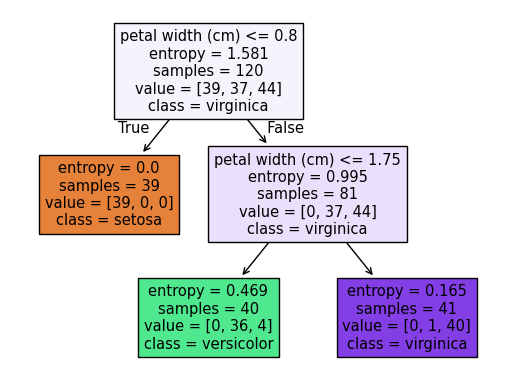

In [79]:
# Putting the feature names and class names into variables
fn = ['sepal length (cm)','sepal width (cm)','petal length (cm)','petal width (cm)']
cn = ['setosa', 'versicolor', 'virginica']

plot_tree(dtc_entropy,
          feature_names = fn, 
          class_names=cn,
          filled = True)

[Text(0.4, 0.8333333333333334, 'petal width (cm) <= 0.8\ngini = 0.665\nsamples = 120\nvalue = [39, 37, 44]\nclass = virginica'),
 Text(0.2, 0.5, 'gini = 0.0\nsamples = 39\nvalue = [39, 0, 0]\nclass = setosa'),
 Text(0.30000000000000004, 0.6666666666666667, 'True  '),
 Text(0.6, 0.5, 'petal width (cm) <= 1.75\ngini = 0.496\nsamples = 81\nvalue = [0, 37, 44]\nclass = virginica'),
 Text(0.5, 0.6666666666666667, '  False'),
 Text(0.4, 0.16666666666666666, 'gini = 0.18\nsamples = 40\nvalue = [0, 36, 4]\nclass = versicolor'),
 Text(0.8, 0.16666666666666666, 'gini = 0.048\nsamples = 41\nvalue = [0, 1, 40]\nclass = virginica')]

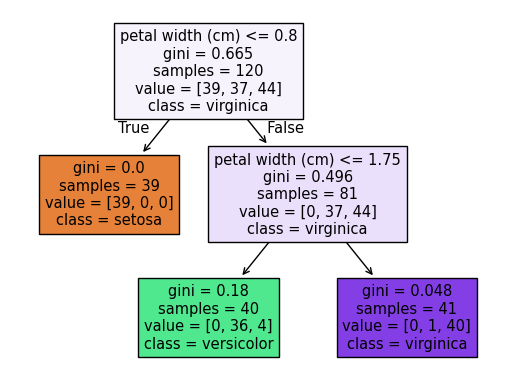

In [80]:
# Putting the feature names and class names into variables
fn = ['sepal length (cm)','sepal width (cm)','petal length (cm)','petal width (cm)']
cn = ['setosa', 'versicolor', 'virginica']

plot_tree(dtc_gini,
          feature_names = fn, 
          class_names=cn,
          filled = True)

<details>
<summary><b>Click me for answer</b></summary>

**The two trees are identical in structure.** Both split on the same features (`petal width`) at the same thresholds (0.8 and 1.75), and every leaf makes the same class prediction. The only difference is the impurity values displayed in each node: the entropy tree shows entropy scores (e.g. 1.581, 0.995, 0.469, 0.165) while the Gini tree shows Gini scores (e.g. 0.665, 0.496, 0.18, 0.048).

**Why this matters:** Gini and entropy are two different measures of node impurity, but they often agree on the best split because they are both maximised when classes are evenly mixed and minimised when a node is pure. On clean, well-separated datasets like Iris, the choice of criterion rarely changes the tree structure. The difference becomes more relevant on noisier datasets where the two measures may disagree on borderline splits.

</details>

# 3. Ensemble Methods

A single decision tree is fast and interpretable, but prone to overfitting. **Ensemble methods** combine many trees to reduce this variance, trading some computational cost for improved accuracy.

| Method | Key idea |
|---|---|
| **Bagging** | Bootstrap-sampled trees, predictions aggregated by majority vote |
| **Random Forest** | Bagging + random feature subset at each split |
| **Boosting** | Trees trained sequentially, each correcting the previous one's errors |

---



### 📊 Breast Cancer Wisconsin Dataset

This loads it and prints full description from the [Breast Cancer Wisconsin dataset](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html)


In [81]:
from sklearn.datasets import load_breast_cancer
print(load_breast_cancer()['DESCR'])
X, y = load_breast_cancer(return_X_y=True)


.. _breast_cancer_dataset:

Breast cancer Wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

- Cell below splits the data into a training set (70% of the data) and a test set (30%). 

- The `stratify` parameter ensures that the proportion of instances of each class in the training and test sets is the same as in the original dataset.


In [82]:
# see above: from sklearn.model_selection import train_test_split
# Split the data into training and testing sets

# Set seed for reproducibility
r_state = 0 # random_state
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.3,
                                                    stratify=y,
                                                    random_state=r_state)

Next we implement **Bagging** and **Random Forest** and compare them to a single tree.


## ℹ️ Bagging

**Bagging** (bootstrap aggregating) trains each tree on a different **bootstrap sample** (rows sampled with replacement), then aggregates predictions by majority vote. Because each tree sees a different data subset, their errors are less correlated and partially cancel out.

---


> **Ensemble Explorer (Bagging)**
>
> Same feature space as the overfitting plot with **sepal length** (x) vs **sepal width** (y) and the same 70/30 train/test split. Filled circles (●) are training samples and diamonds (◇) are test samples. Toggle buttons T1 through T8 control eight individual decision trees, each trained on a different bootstrap sample. The **Ensemble** button shows the majority vote of all eight trees. Shaded regions show the prediction boundary of whichever trees are active. Red ringed diamonds highlight misclassified test samples and the error count updates live.
>
> *Turn on a single tree and count the errors, then switch to the ensemble. The boundary smooths out and errors drop. Toggle different trees to see how much they disagree in the overlapping region.*

In [83]:
from IPython.display import HTML
HTML('<div style="overflow:hidden; height:540px;"><iframe src="data:text/html;base64,PCFET0NUWVBFIGh0bWw+CjxodG1sIGxhbmc9ImVuIj4KPGhlYWQ+CjxtZXRhIGNoYXJzZXQ9IlVURi04Ij4KPG1ldGEgbmFtZT0idmlld3BvcnQiIGNvbnRlbnQ9IndpZHRoPWRldmljZS13aWR0aCwgaW5pdGlhbC1zY2FsZT0xLjAiPgo8dGl0bGU+RW5zZW1ibGUgRXhwbG9yZXI8L3RpdGxlPgo8c3R5bGU+CiAgQGltcG9ydCB1cmwoJ2h0dHBzOi8vZm9udHMuZ29vZ2xlYXBpcy5jb20vY3NzMj9mYW1pbHk9RE0rU2Fuczp3Z2h0QDQwMDs1MDA7NzAwJmZhbWlseT1KZXRCcmFpbnMrTW9ubzp3Z2h0QDQwMDs2MDAmZGlzcGxheT1zd2FwJyk7CiAgKnttYXJnaW46MDtwYWRkaW5nOjA7Ym94LXNpemluZzpib3JkZXItYm94fQogIGJvZHl7Zm9udC1mYW1pbHk6J0RNIFNhbnMnLHNhbnMtc2VyaWY7YmFja2dyb3VuZDojMGYxMTE3O2NvbG9yOiNkNGQ0ZTA7ZGlzcGxheTpmbGV4O2ZsZXgtZGlyZWN0aW9uOmNvbHVtbjthbGlnbi1pdGVtczpjZW50ZXI7cGFkZGluZzoyNHB4fQogIC5oZWFkZXJ7d2lkdGg6MTAwJTttYXgtd2lkdGg6NzAwcHg7bWFyZ2luLWJvdHRvbToxNHB4fQogIGgye2ZvbnQtc2l6ZToxLjNyZW07Zm9udC13ZWlnaHQ6NzAwO2NvbG9yOiNmZmY7bWFyZ2luLWJvdHRvbToxMHB4fQogIC50b2dnbGUtYmFye2Rpc3BsYXk6ZmxleDtnYXA6NXB4O2ZsZXgtd3JhcDp3cmFwO2JhY2tncm91bmQ6IzE4MWEyNDtib3JkZXItcmFkaXVzOjhweDtwYWRkaW5nOjVweCA4cHg7Ym9yZGVyOjFweCBzb2xpZCAjMjUyODM4O3dpZHRoOmZpdC1jb250ZW50O2FsaWduLWl0ZW1zOmNlbnRlcn0KICAudGJ0bntmb250LWZhbWlseTonSmV0QnJhaW5zIE1vbm8nLG1vbm9zcGFjZTtmb250LXNpemU6Ljc4cmVtO3BhZGRpbmc6NXB4IDEwcHg7Ym9yZGVyLXJhZGl1czo1cHg7Ym9yZGVyOjJweCBzb2xpZCAjMmQzMDUwO2JhY2tncm91bmQ6dHJhbnNwYXJlbnQ7Y29sb3I6IzY4NzhhMDtjdXJzb3I6cG9pbnRlcjt0cmFuc2l0aW9uOi4yc30KICAudGJ0bjpob3ZlcntiYWNrZ3JvdW5kOnJnYmEoMjU1LDI1NSwyNTUsLjA0KX0KICAudGJ0bi5vbntjb2xvcjojZmZmO2JhY2tncm91bmQ6cmdiYSgyNTUsMjU1LDI1NSwuMDYpfQogIC50YnRuLmVuc3tib3JkZXItY29sb3I6I2ZmZDk2Nn0KICAudGJ0bi5lbnMub257Y29sb3I6I2ZmZDk2NjtiYWNrZ3JvdW5kOnJnYmEoMjU1LDIxNywxMDIsLjA4KX0KICAudml6e3Bvc2l0aW9uOnJlbGF0aXZlO2JhY2tncm91bmQ6IzE4MWEyNDtib3JkZXItcmFkaXVzOjE0cHg7cGFkZGluZzoxOHB4O2JvcmRlcjoxcHggc29saWQgIzI1MjgzODttYXgtd2lkdGg6NzAwcHg7d2lkdGg6MTAwJX0KICBjYW52YXN7ZGlzcGxheTpibG9jaztib3JkZXItcmFkaXVzOjZweDt3aWR0aDoxMDAlfQogIC5ib3R0b20tYmFye2Rpc3BsYXk6ZmxleDtqdXN0aWZ5LWNvbnRlbnQ6c3BhY2UtYmV0d2VlbjthbGlnbi1pdGVtczpjZW50ZXI7bWFyZ2luLXRvcDoxMHB4O2ZsZXgtd3JhcDp3cmFwO2dhcDo4cHh9CiAgLmxlZ2VuZHtkaXNwbGF5OmZsZXg7Z2FwOjE0cHh9CiAgLmxlZ2VuZC1pdGVte2Rpc3BsYXk6ZmxleDthbGlnbi1pdGVtczpjZW50ZXI7Z2FwOjVweDtmb250LXNpemU6Ljc2cmVtO2NvbG9yOiM5YWF9CiAgLmxlZ2VuZC1kb3R7d2lkdGg6OHB4O2hlaWdodDo4cHg7Ym9yZGVyLXJhZGl1czo1MCV9CiAgLmFjYy1kaXNwbGF5e2ZvbnQtZmFtaWx5OidKZXRCcmFpbnMgTW9ubycsbW9ub3NwYWNlO2ZvbnQtc2l6ZTouODRyZW07ZGlzcGxheTpmbGV4O2dhcDoxNnB4fQogIC5hY2MtZGlzcGxheSAuZW5zLWFjY3tjb2xvcjojZmZkOTY2fQogIC5hY2MtZGlzcGxheSAuYmVzdC10cmVle2NvbG9yOiM4ODk4Yjh9Cjwvc3R5bGU+CjwvaGVhZD4KPGJvZHk+CjxkaXYgY2xhc3M9ImhlYWRlciI+CiAgPGgyPkJhZ2dpbmcgRXhwbG9yZXI8L2gyPgogIDxkaXYgY2xhc3M9InRvZ2dsZS1iYXIiIGlkPSJiYXIiPgogICAgPGJ1dHRvbiBjbGFzcz0idGJ0biBlbnMgb24iIGRhdGEtdD0iZW5zIj5FbnNlbWJsZTwvYnV0dG9uPgogIDwvZGl2Pgo8L2Rpdj4KPGRpdiBjbGFzcz0idml6Ij4KICA8Y2FudmFzIGlkPSJjIiBoZWlnaHQ9IjQyMCI+PC9jYW52YXM+CiAgPGRpdiBjbGFzcz0iYm90dG9tLWJhciI+CiAgICA8ZGl2IGNsYXNzPSJsZWdlbmQiPgogICAgICA8ZGl2IGNsYXNzPSJsZWdlbmQtaXRlbSI+PGRpdiBjbGFzcz0ibGVnZW5kLWRvdCIgc3R5bGU9ImJhY2tncm91bmQ6I2ZmNmI4YSI+PC9kaXY+U2V0b3NhPC9kaXY+CiAgICAgIDxkaXYgY2xhc3M9ImxlZ2VuZC1pdGVtIj48ZGl2IGNsYXNzPSJsZWdlbmQtZG90IiBzdHlsZT0iYmFja2dyb3VuZDojNGVjZGM0Ij48L2Rpdj5WZXJzaWNvbG9yPC9kaXY+CiAgICAgIDxkaXYgY2xhc3M9ImxlZ2VuZC1pdGVtIj48ZGl2IGNsYXNzPSJsZWdlbmQtZG90IiBzdHlsZT0iYmFja2dyb3VuZDojNmE2ZGZhIj48L2Rpdj5WaXJnaW5pY2E8L2Rpdj4KICAgICAgPGRpdiBjbGFzcz0ibGVnZW5kLWl0ZW0iPjxzcGFuIHN0eWxlPSJjb2xvcjojYmJjIj7il488L3NwYW4+IFRyYWluPC9kaXY+CiAgICAgIDxkaXYgY2xhc3M9ImxlZ2VuZC1pdGVtIj48c3BhbiBzdHlsZT0iY29sb3I6I2JiYyI+4peHPC9zcGFuPiBUZXN0PC9kaXY+CiAgICAgIDxkaXYgY2xhc3M9ImxlZ2VuZC1pdGVtIj48ZGl2IGNsYXNzPSJsZWdlbmQtZG90IiBzdHlsZT0iYmFja2dyb3VuZDojZmY0NDQ0O2JveC1zaGFkb3c6MCAwIDRweCAjZjQ0Ij48L2Rpdj5Xcm9uZzwvZGl2PgogICAgPC9kaXY+CiAgICA8ZGl2IGNsYXNzPSJhY2MtZGlzcGxheSI+CiAgICAgIDxzcGFuIHN0eWxlPSJjb2xvcjojNzA4MGEwIj5FcnJvcnM6IDxzcGFuIGlkPSJlcnJDb3VudCIgc3R5bGU9ImZvbnQtZmFtaWx5OidKZXRCcmFpbnMgTW9ubycsbW9ub3NwYWNlO2ZvbnQtd2VpZ2h0OjcwMDt0cmFuc2l0aW9uOmNvbG9yIC4zcyI+4oCUPC9zcGFuPjwvc3Bhbj4KICAgICAgPHNwYW4gY2xhc3M9ImVucy1hY2MiPkVuc2VtYmxlOiA8c3BhbiBpZD0iZW5zQWNjIj7igJQ8L3NwYW4+PC9zcGFuPgogICAgICA8c3BhbiBjbGFzcz0iYmVzdC10cmVlIj5CZXN0IHRyZWU6IDxzcGFuIGlkPSJiZXN0QWNjIj7igJQ8L3NwYW4+PC9zcGFuPgogICAgPC9kaXY+CiAgPC9kaXY+CjwvZGl2PgoKPHNjcmlwdD4KY29uc3QgaXJpcz1bCls1LjEsMy41LDEuNCwuMiwwXSxbNC45LDMsMS40LC4yLDBdLFs0LjcsMy4yLDEuMywuMiwwXSxbNC42LDMuMSwxLjUsLjIsMF0sWzUsMy42LDEuNCwuMiwwXSwKWzUuNCwzLjksMS43LC40LDBdLFs0LjYsMy40LDEuNCwuMywwXSxbNSwzLjQsMS41LC4yLDBdLFs0LjQsMi45LDEuNCwuMiwwXSxbNC45LDMuMSwxLjUsLjEsMF0sCls1LjQsMy43LDEuNSwuMiwwXSxbNC44LDMuNCwxLjYsLjIsMF0sWzQuOCwzLDEuNCwuMSwwXSxbNC4zLDMsMS4xLC4xLDBdLFs1LjgsNCwxLjIsLjIsMF0sCls1LjcsNC40LDEuNSwuNCwwXSxbNS40LDMuOSwxLjMsLjQsMF0sWzUuMSwzLjUsMS40LC4zLDBdLFs1LjcsMy44LDEuNywuMywwXSxbNS4xLDMuOCwxLjUsLjMsMF0sCls1LjQsMy40LDEuNywuMiwwXSxbNS4xLDMuNywxLjUsLjQsMF0sWzQuNiwzLjYsMSwuMiwwXSxbNS4xLDMuMywxLjcsLjUsMF0sWzQuOCwzLjQsMS45LC4yLDBdLApbNSwzLDEuNiwuMiwwXSxbNSwzLjQsMS42LC40LDBdLFs1LjIsMy41LDEuNSwuMiwwXSxbNS4yLDMuNCwxLjQsLjIsMF0sWzQuNywzLjIsMS42LC4yLDBdLApbNC44LDMuMSwxLjYsLjIsMF0sWzUuNCwzLjQsMS41LC40LDBdLFs1LjIsNC4xLDEuNSwuMSwwXSxbNS41LDQuMiwxLjQsLjIsMF0sWzQuOSwzLjEsMS41LC4yLDBdLApbNSwzLjIsMS4yLC4yLDBdLFs1LjUsMy41LDEuMywuMiwwXSxbNC45LDMuNiwxLjQsLjEsMF0sWzQuNCwzLDEuMywuMiwwXSxbNS4xLDMuNCwxLjUsLjIsMF0sCls1LDMuNSwxLjMsLjMsMF0sWzQuNSwyLjMsMS4zLC4zLDBdLFs0LjQsMy4yLDEuMywuMiwwXSxbNSwzLjUsMS42LC42LDBdLFs1LjEsMy44LDEuOSwuNCwwXSwKWzQuOCwzLDEuNCwuMywwXSxbNS4xLDMuOCwxLjYsLjIsMF0sWzQuNiwzLjIsMS40LC4yLDBdLFs1LjMsMy43LDEuNSwuMiwwXSxbNSwzLjMsMS40LC4yLDBdLApbNywzLjIsNC43LDEuNCwxXSxbNi40LDMuMiw0LjUsMS41LDFdLFs2LjksMy4xLDQuOSwxLjUsMV0sWzUuNSwyLjMsNCwxLjMsMV0sWzYuNSwyLjgsNC42LDEuNSwxXSwKWzUuNywyLjgsNC41LDEuMywxXSxbNi4zLDMuMyw0LjcsMS42LDFdLFs0LjksMi40LDMuMywxLDFdLFs2LjYsMi45LDQuNiwxLjMsMV0sWzUuMiwyLjcsMy45LDEuNCwxXSwKWzUsMiwzLjUsMSwxXSxbNS45LDMsNC4yLDEuNSwxXSxbNiwyLjIsNCwxLDFdLFs2LjEsMi45LDQuNywxLjQsMV0sWzUuNiwyLjksMy42LDEuMywxXSwKWzYuNywzLjEsNC40LDEuNCwxXSxbNS42LDMsNC41LDEuNSwxXSxbNS44LDIuNyw0LjEsMSwxXSxbNi4yLDIuMiw0LjUsMS41LDFdLFs1LjYsMi41LDMuOSwxLjEsMV0sCls1LjksMy4yLDQuOCwxLjgsMV0sWzYuMSwyLjgsNCwxLjMsMV0sWzYuMywyLjUsNC45LDEuNSwxXSxbNi4xLDIuOCw0LjcsMS4yLDFdLFs2LjQsMi45LDQuMywxLjMsMV0sCls2LjYsMyw0LjQsMS40LDFdLFs2LjgsMi44LDQuOCwxLjQsMV0sWzYuNywzLDUsMS43LDFdLFs2LDIuOSw0LjUsMS41LDFdLFs1LjcsMi42LDMuNSwxLDFdLApbNS41LDIuNCwzLjgsMS4xLDFdLFs1LjUsMi40LDMuNywxLDFdLFs1LjgsMi43LDMuOSwxLjIsMV0sWzYsMi43LDUuMSwxLjYsMV0sWzUuNCwzLDQuNSwxLjUsMV0sCls2LDMuNCw0LjUsMS42LDFdLFs2LjcsMy4xLDQuNywxLjUsMV0sWzYuMywyLjMsNC40LDEuMywxXSxbNS42LDMsNC4xLDEuMywxXSxbNS41LDIuNSw0LDEuMywxXSwKWzUuNSwyLjYsNC40LDEuMiwxXSxbNi4xLDMsNC42LDEuNCwxXSxbNS44LDIuNiw0LDEuMiwxXSxbNSwyLjMsMy4zLDEsMV0sWzUuNiwyLjcsNC4yLDEuMywxXSwKWzUuNywzLDQuMiwxLjIsMV0sWzUuNywyLjksNC4yLDEuMywxXSxbNi4yLDIuOSw0LjMsMS4zLDFdLFs1LjEsMi41LDMsMS4xLDFdLFs1LjcsMi44LDQuMSwxLjMsMV0sCls2LjMsMy4zLDYsMi41LDJdLFs1LjgsMi43LDUuMSwxLjksMl0sWzcuMSwzLDUuOSwyLjEsMl0sWzYuMywyLjksNS42LDEuOCwyXSxbNi41LDMsNS44LDEuOCwyXSwKWzcuNiwzLDYuNiwyLjEsMl0sWzQuOSwyLjUsNC41LDEuNywyXSxbNy4zLDIuOSw2LjMsMS44LDJdLFs2LjcsMi41LDUuOCwxLjgsMl0sWzcuMiwzLjYsNi4xLDIuNSwyXSwKWzYuNSwzLjIsNS4xLDIsMl0sWzYuNCwyLjcsNS4zLDEuOSwyXSxbNi44LDMsNS41LDIuMSwyXSxbNS43LDIuNSw1LDIsMl0sWzUuOCwyLjgsNS4xLDIuNCwyXSwKWzYuNCwzLjIsNS4zLDIuMywyXSxbNi41LDMsNS41LDEuOCwyXSxbNy43LDMuOCw2LjcsMi4yLDJdLFs3LjcsMi42LDYuOSwyLjMsMl0sWzYsMi4yLDUsMS41LDJdLApbNi45LDMuMiw1LjcsMi4zLDJdLFs1LjYsMi44LDQuOSwyLDJdLFs3LjcsMi44LDYuNywyLDJdLFs2LjMsMi43LDQuOSwxLjgsMl0sWzYuNywzLjMsNS43LDIuMSwyXSwKWzcuMiwzLjIsNiwxLjgsMl0sWzYuMiwyLjgsNC44LDEuOCwyXSxbNi4xLDMsNC45LDEuOCwyXSxbNi40LDIuOCw1LjYsMi4xLDJdLFs3LjIsMyw1LjgsMS42LDJdLApbNy40LDIuOCw2LjEsMS45LDJdLFs3LjksMy44LDYuNCwyLDJdLFs2LjQsMi44LDUuNiwyLjIsMl0sWzYuMywyLjgsNS4xLDEuNSwyXSxbNi4xLDIuNiw1LjYsMS40LDJdLApbNy43LDMsNi4xLDIuMywyXSxbNi4zLDMuNCw1LjQsMi4zLDJdLFs2LjQsMy4xLDUuNSwxLjgsMl0sWzYsMyw0LjgsMS44LDJdLFs2LjksMy4xLDUuNCwyLjEsMl0sCls2LjcsMy4xLDUuNiwyLjQsMl0sWzYuOSwzLjEsNS4xLDIuMywyXSxbNS44LDIuNyw1LjEsMS45LDJdLFs2LjgsMy4yLDUuOSwyLjMsMl0sWzYuNywzLjMsNS43LDIuNSwyXSwKWzYuNywzLDUuMiwyLjMsMl0sWzYuMywyLjUsNSwxLjksMl0sWzYuNSwzLDUuMiwyLDJdLFs2LjIsMy40LDUuNCwyLjMsMl0sWzUuOSwzLDUuMSwxLjgsMl1dOwoKY29uc3QgZDI9aXJpcy5tYXAocj0+W3JbMF0sclsxXSxyWzRdXSk7CmZ1bmN0aW9uIHNodWYoYSxzKXtjb25zdCByPVsuLi5hXTtmb3IobGV0IGk9ci5sZW5ndGgtMTtpPjA7aS0tKXtzPShzKjE2ODA3KSUyMTQ3NDgzNjQ3O2NvbnN0IGo9cyUoaSsxKTtbcltpXSxyW2pdXT1bcltqXSxyW2ldXX1yZXR1cm4gcn0KY29uc3QgaWR4PXNodWYoWy4uLkFycmF5KDE1MCkua2V5cygpXSw0Mik7CmNvbnN0IHRyST1uZXcgU2V0KGlkeC5zbGljZSgwLDEwNSkpLHRyRD1kMi5maWx0ZXIoKF8saSk9PnRySS5oYXMoaSkpLHRlRD1kMi5maWx0ZXIoKF8saSk9PiF0ckkuaGFzKGkpKTsKCmZ1bmN0aW9uIGJ1aWxkKGRhdGEsbWQsZD0wKXsKICBjb25zdCBjPVswLDAsMF07Zm9yKGNvbnN0IHggb2YgZGF0YSljW3hbMl1dKys7Y29uc3QgbWFqPWMuaW5kZXhPZihNYXRoLm1heCguLi5jKSk7CiAgaWYoZD49bWR8fGRhdGEubGVuZ3RoPD0yfHxjLmZpbHRlcih2PT52PjApLmxlbmd0aD09PTEpcmV0dXJue2w6dHJ1ZSxjOm1han07CiAgbGV0IGJnPUluZmluaXR5LGJmPTAsYnQ9MCxibCxicjsKICBmb3IobGV0IGY9MDtmPDI7ZisrKXtjb25zdCB2PVsuLi5uZXcgU2V0KGRhdGEubWFwKHg9PnhbZl0pKV0uc29ydCgoYSxiKT0+YS1iKTsKICAgIGZvcihsZXQgaT0wO2k8di5sZW5ndGgtMTtpKyspe2NvbnN0IHQ9KHZbaV0rdltpKzFdKS8yLGw9ZGF0YS5maWx0ZXIoeD0+eFtmXTw9dCkscj1kYXRhLmZpbHRlcih4PT54W2ZdPnQpOwogICAgICBpZighbC5sZW5ndGh8fCFyLmxlbmd0aCljb250aW51ZTtjb25zdCBsYz1bMCwwLDBdLHJjPVswLDAsMF07CiAgICAgIGZvcihjb25zdCB4IG9mIGwpbGNbeFsyXV0rKztmb3IoY29uc3QgeCBvZiByKXJjW3hbMl1dKys7CiAgICAgIGNvbnN0IGcxPTEtbGMucmVkdWNlKChzLHYpPT5zKyh2L2wubGVuZ3RoKSoqMiwwKSxnMj0xLXJjLnJlZHVjZSgocyx2KT0+cysodi9yLmxlbmd0aCkqKjIsMCksd2c9KGwubGVuZ3RoKmcxK3IubGVuZ3RoKmcyKS9kYXRhLmxlbmd0aDsKICAgICAgaWYod2c8Ymcpe2JnPXdnO2JmPWY7YnQ9dDtibD1sO2JyPXJ9fX0KICBpZighYmwpcmV0dXJue2w6dHJ1ZSxjOm1han07CiAgcmV0dXJue2w6ZmFsc2UsZjpiZix0OmJ0LGxlZnQ6YnVpbGQoYmwsbWQsZCsxKSxyaWdodDpidWlsZChicixtZCxkKzEpfTsKfQpmdW5jdGlvbiBwcmVkKHQseCl7cmV0dXJuIHQubD90LmM6eFt0LmZdPD10LnQ/cHJlZCh0LmxlZnQseCk6cHJlZCh0LnJpZ2h0LHgpfQpmdW5jdGlvbiBhY2ModCxkKXtsZXQgYz0wO2Zvcihjb25zdCB4IG9mIGQpaWYocHJlZCh0LHgpPT09eFsyXSljKys7cmV0dXJuIGMvZC5sZW5ndGh9Cgpjb25zdCBOVD04LHRDb2xzPVsnI2UwNmM3NScsJyM5OGMzNzknLCcjNjFhZmVmJywnI2M2NzhkZCcsJyNlNWMwN2InLCcjNTZiNmMyJywnI2JlNTA0NicsJyNkMTlhNjYnXTsKY29uc3QgYWxsVD1bXSx0QWNjPVtdO2NvbnN0IHRBY3Q9bmV3IEFycmF5KE5UKS5maWxsKGZhbHNlKTtsZXQgZW5zT249dHJ1ZTsKZnVuY3Rpb24gbGNnKHMpe3JldHVybihzKjE2ODA3KSUyMTQ3NDgzNjQ3fQpmb3IobGV0IHQ9MDt0PE5UO3QrKyl7bGV0IHM9MTAwK3QqMzc7Y29uc3QgYnM9W107Zm9yKGxldCBpPTA7aTx0ckQubGVuZ3RoO2krKyl7cz1sY2cocyk7YnMucHVzaCh0ckRbcyV0ckQubGVuZ3RoXSl9CiAgY29uc3QgdHJlZT1idWlsZChicyw0KTthbGxULnB1c2godHJlZSk7dEFjYy5wdXNoKGFjYyh0cmVlLHRlRCkpfQpmdW5jdGlvbiBlbnNQcmVkKHgsc2VsKXtjb25zdCB2PVswLDAsMF07Y29uc3QgdHM9c2VsfHxbLi4uQXJyYXkoTlQpLmtleXMoKV07Zm9yKGNvbnN0IHQgb2YgdHMpdltwcmVkKGFsbFRbdF0seCldKys7cmV0dXJuIHYuaW5kZXhPZihNYXRoLm1heCguLi52KSl9CmNvbnN0IGVuc0FjY1ZhbEFsbD0oKCk9PntsZXQgYz0wO2Zvcihjb25zdCBkIG9mIHRlRClpZihlbnNQcmVkKGQpPT09ZFsyXSljKys7cmV0dXJuIGMvdGVELmxlbmd0aH0pKCk7CgovLyBUb2dnbGUgYnV0dG9ucwpjb25zdCBiYXI9ZG9jdW1lbnQuZ2V0RWxlbWVudEJ5SWQoJ2JhcicpOwpmb3IobGV0IHQ9MDt0PE5UO3QrKyl7CiAgY29uc3QgYj1kb2N1bWVudC5jcmVhdGVFbGVtZW50KCdidXR0b24nKTtiLmNsYXNzTmFtZT0ndGJ0bic7Yi5kYXRhc2V0LnQ9dDtiLnRleHRDb250ZW50PWBUJHt0KzF9YDsKICBiLmFkZEV2ZW50TGlzdGVuZXIoJ2NsaWNrJywoKT0+e3RBY3RbdF09IXRBY3RbdF07Yi5jbGFzc0xpc3QudG9nZ2xlKCdvbicpO2Iuc3R5bGUuYm9yZGVyQ29sb3I9dEFjdFt0XT90Q29sc1t0XTonIzJkMzA1MCc7Yi5zdHlsZS5jb2xvcj10QWN0W3RdP3RDb2xzW3RdOicjNjg3OGEwJztkcmF3KCl9KTsKICBiYXIuYXBwZW5kQ2hpbGQoYik7Cn0KZG9jdW1lbnQucXVlcnlTZWxlY3RvcignW2RhdGEtdD0iZW5zIl0nKS5hZGRFdmVudExpc3RlbmVyKCdjbGljaycsKCk9PntlbnNPbj0hZW5zT247ZG9jdW1lbnQucXVlcnlTZWxlY3RvcignW2RhdGEtdD0iZW5zIl0nKS5jbGFzc0xpc3QudG9nZ2xlKCdvbicpO2RyYXcoKX0pOwoKY29uc3QgY3Y9ZG9jdW1lbnQuZ2V0RWxlbWVudEJ5SWQoJ2MnKSxjdHg9Y3YuZ2V0Q29udGV4dCgnMmQnKTsKY29uc3QgVz02NjAsSD00MjAsZHByPXdpbmRvdy5kZXZpY2VQaXhlbFJhdGlvfHwxOwpjdi53aWR0aD1XKmRwcjtjdi5oZWlnaHQ9SCpkcHI7Y3Yuc3R5bGUud2lkdGg9VysncHgnO2N2LnN0eWxlLmhlaWdodD1IKydweCc7Y3R4LnNjYWxlKGRwcixkcHIpOwpjb25zdCBQPXt0OjIwLHI6MjIsYjo0MixsOjQ4fSxwdz1XLVAubC1QLnIscGg9SC1QLnQtUC5iOwpjb25zdCB4TW49NCx4TXg9OC4yLHlNbj0xLjgseU14PTQuNjsKY29uc3QgY2xzPVsnI2ZmNmI4YScsJyM0ZWNkYzQnLCcjNmE2ZGZhJ107CgpmdW5jdGlvbiBkcmF3KCl7CiAgY3R4LmNsZWFyUmVjdCgwLDAsVyxIKTsKICBjb25zdCBhY3Q9W107Zm9yKGxldCB0PTA7dDxOVDt0KyspaWYodEFjdFt0XSlhY3QucHVzaCh0KTsKICBjb25zdCByZXM9NDsKICBmb3IobGV0IHB4PVAubDtweDxQLmwrcHc7cHgrPXJlcylmb3IobGV0IHB5PVAudDtweTxQLnQrcGg7cHkrPXJlcyl7CiAgICBjb25zdCB4dj14TW4rKChweC1QLmwpL3B3KSooeE14LXhNbikseXY9eU14LSgocHktUC50KS9waCkqKHlNeC15TW4pOwogICAgbGV0IGM7CiAgICBpZihlbnNPbiYmIWFjdC5sZW5ndGgpYz1lbnNQcmVkKFt4dix5dl0pOwogICAgZWxzZSBpZihhY3QubGVuZ3RoKXtjb25zdCB2PVswLDAsMF07Zm9yKGNvbnN0IHQgb2YgYWN0KXZbcHJlZChhbGxUW3RdLFt4dix5dl0pXSsrO2M9di5pbmRleE9mKE1hdGgubWF4KC4uLnYpKX0KICAgIGVsc2UgY29udGludWU7CiAgICBjb25zdCBoZXg9Y2xzW2NdLHI9cGFyc2VJbnQoaGV4LnNsaWNlKDEsMyksMTYpLGc9cGFyc2VJbnQoaGV4LnNsaWNlKDMsNSksMTYpLGI9cGFyc2VJbnQoaGV4LnNsaWNlKDUsNyksMTYpOwogICAgY29uc3QgYT1hY3QubGVuZ3RoPy4wOCsuMDQqYWN0Lmxlbmd0aDouMTQ7CiAgICBjdHguZmlsbFN0eWxlPWByZ2JhKCR7cn0sJHtnfSwke2J9LCR7YX0pYDtjdHguZmlsbFJlY3QocHgscHkscmVzLHJlcyk7CiAgfQogIGN0eC5zdHJva2VTdHlsZT0nIzI1MjgzOCc7Y3R4LmxpbmVXaWR0aD0xO2N0eC5zdHJva2VSZWN0KFAubCxQLnQscHcscGgpOwogIGN0eC5maWxsU3R5bGU9JyM4ODk4YjgnO2N0eC5mb250PScxMHB4ICJKZXRCcmFpbnMgTW9ubyInO2N0eC50ZXh0QWxpZ249J2NlbnRlcic7CiAgZm9yKGxldCB2PTQ7djw9ODt2Kyspe2NvbnN0IHg9UC5sKygodi14TW4pLyh4TXgteE1uKSkqcHc7Y3R4LmZpbGxUZXh0KHYseCxQLnQrcGgrMTYpfQogIGN0eC5maWxsU3R5bGU9JyNhMGFhYzgnO2N0eC5mb250PScxMXB4ICJETSBTYW5zIic7Y3R4LmZpbGxUZXh0KCdTZXBhbCBMZW5ndGgnLFAubCtwdy8yLFAudCtwaCszNik7CiAgY3R4LnRleHRBbGlnbj0ncmlnaHQnO2N0eC5maWxsU3R5bGU9JyM4ODk4YjgnO2N0eC5mb250PScxMHB4ICJKZXRCcmFpbnMgTW9ubyInOwogIGZvcihsZXQgdj0yO3Y8PTQuNTt2Kz0uNSl7Y29uc3QgeT1QLnQrcGgtKCh2LXlNbikvKHlNeC15TW4pKSpwaDtjdHguZmlsbFRleHQodi50b0ZpeGVkKDEpLFAubC02LHkrMyl9CiAgLy8gVHJhaW4gcG9pbnRzIChjaXJjbGVzKQogIGZvcihjb25zdCBkIG9mIHRyRCl7Y29uc3QgeD1QLmwrKChkWzBdLXhNbikvKHhNeC14TW4pKSpwdyx5PVAudCtwaC0oKGRbMV0teU1uKS8oeU14LXlNbikpKnBoOwogICAgY3R4LmJlZ2luUGF0aCgpO2N0eC5hcmMoeCx5LDMuNSwwLE1hdGguUEkqMik7Y3R4LmZpbGxTdHlsZT1jbHNbZFsyXV07Y3R4Lmdsb2JhbEFscGhhPS42NTtjdHguZmlsbCgpO2N0eC5nbG9iYWxBbHBoYT0xfQoKICAvLyBDdXJyZW50IHByZWRpY3Rpb24gZnVuY3Rpb24gYmFzZWQgb24gYWN0aXZlIHRvZ2dsZXMKICBmdW5jdGlvbiBjdXJQcmVkKHB0KXsKICAgIGlmKGVuc09uJiYhYWN0Lmxlbmd0aClyZXR1cm4gZW5zUHJlZChwdCk7CiAgICBpZihhY3QubGVuZ3RoKXtjb25zdCB2PVswLDAsMF07Zm9yKGNvbnN0IHQgb2YgYWN0KXZbcHJlZChhbGxUW3RdLHB0KV0rKztyZXR1cm4gdi5pbmRleE9mKE1hdGgubWF4KC4uLnYpKX0KICAgIHJldHVybiBlbnNQcmVkKHB0KTsgLy8gZmFsbGJhY2sKICB9CgogIC8vIFRlc3QgcG9pbnRzIChkaWFtb25kcykgd2l0aCBtaXNjbGFzc2lmaWNhdGlvbiBoaWdobGlnaHRzCiAgbGV0IG1pc3M9MDsKICBmb3IoY29uc3QgZCBvZiB0ZUQpewogICAgY29uc3QgeD1QLmwrKChkWzBdLXhNbikvKHhNeC14TW4pKSpwdyx5PVAudCtwaC0oKGRbMV0teU1uKS8oeU14LXlNbikpKnBoOwogICAgY29uc3Qgd3Jvbmc9Y3VyUHJlZChkKSE9PWRbMl07aWYod3JvbmcpbWlzcysrOwogICAgY3R4LmJlZ2luUGF0aCgpO2N0eC5tb3ZlVG8oeCx5LTYpO2N0eC5saW5lVG8oeCs2LHkpO2N0eC5saW5lVG8oeCx5KzYpO2N0eC5saW5lVG8oeC02LHkpO2N0eC5jbG9zZVBhdGgoKTsKICAgIGN0eC5zdHJva2VTdHlsZT13cm9uZz8nI2ZmNDQ0NCc6Y2xzW2RbMl1dO2N0eC5saW5lV2lkdGg9d3Jvbmc/Mi41OjI7Y3R4LnN0cm9rZSgpOwogICAgaWYod3Jvbmcpe2N0eC5iZWdpblBhdGgoKTtjdHguYXJjKHgseSwxMSwwLE1hdGguUEkqMik7Y3R4LnN0cm9rZVN0eWxlPSdyZ2JhKDI1NSw2OCw2OCwuNDUpJztjdHgubGluZVdpZHRoPTEuNTtjdHguc3Ryb2tlKCl9CiAgfQoKICAvLyBDb21wdXRlIGVuc2VtYmxlIGFjY3VyYWN5IGJhc2VkIG9uIGFjdGl2ZSBzZWxlY3Rpb24KICBjb25zdCBlbnNUcmVlU2V0PWFjdC5sZW5ndGg/YWN0OlsuLi5BcnJheShOVCkua2V5cygpXTsKICBsZXQgZW5zQ29ycj0wO2Zvcihjb25zdCBkIG9mIHRlRClpZihlbnNQcmVkKGQsZW5zVHJlZVNldCk9PT1kWzJdKWVuc0NvcnIrKzsKICBjb25zdCBjdXJFbnNBY2M9ZW5zQ29yci90ZUQubGVuZ3RoOwogIGRvY3VtZW50LmdldEVsZW1lbnRCeUlkKCdlbnNBY2MnKS50ZXh0Q29udGVudD0oY3VyRW5zQWNjKjEwMCkudG9GaXhlZCgxKSsnJSc7CiAgZG9jdW1lbnQuZ2V0RWxlbWVudEJ5SWQoJ2Jlc3RBY2MnKS50ZXh0Q29udGVudD0oTWF0aC5tYXgoLi4udEFjYykqMTAwKS50b0ZpeGVkKDEpKyclJzsKICBjb25zdCBlcnJFbD1kb2N1bWVudC5nZXRFbGVtZW50QnlJZCgnZXJyQ291bnQnKTsKICBlcnJFbC50ZXh0Q29udGVudD1taXNzKycgLyAnK3RlRC5sZW5ndGg7CiAgZXJyRWwuc3R5bGUuY29sb3I9bWlzczw9NT8nIzY2Y2M2Nic6bWlzczw9MTA/JyNmZmQ5NjYnOicjZmY2YjhhJzsKfQpkcmF3KCk7Cjwvc2NyaXB0Pgo8L2JvZHk+CjwvaHRtbD4K" width="100%" height="765" style="border:none; transform:scale(0.85); transform-origin:top center;"></iframe></div>')

### 📝 Exercise 4

#### Part 1: Initialize a Bagging Classifier

Create a `BaggingClassifier` using a `DecisionTreeClassifier` (with `max_depth=4`) as the base estimator. See the [BaggingClassifier docs](https://scikit-learn.org/1.5/modules/generated/sklearn.ensemble.BaggingClassifier.html).


In [84]:
# see above: from sklearn.tree import DecisionTreeClassifier
# see above: from sklearn.ensemble import BaggingClassifier

# Make an instance of the Decision Tree Classifier
dtc = DecisionTreeClassifier(max_depth=4, random_state=0)
# Make an instance of the Bagging Classifier
bc = BaggingClassifier(estimator=dtc, n_estimators=10, random_state=0)

#### Part 2: Train the Bagging Classifier

Call `.fit()` on your `bc` with the training data.


In [85]:
# Train the model on the data (train set)
bc.fit(X_train, y_train)

,"estimator estimator: object, default=NoneThe base estimator to fit on random subsets of the dataset.If None, then the base estimator is a:class:`~sklearn.tree.DecisionTreeClassifier`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeC...andom_state=0)
,"n_estimators n_estimators: int, default=10The number of base estimators in the ensemble.",10
,"max_samples max_samples: int or float, default=NoneThe number of samples to draw from X to train each base estimator (withreplacement by default, see `bootstrap` for more details).- If None, then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples.",None
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator (without replacement by default, see `bootstrap_features` for moredetails).- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.",1.0
,"bootstrap bootstrap: bool, default=TrueWhether samples are drawn with replacement. If False, sampling withoutreplacement is performed. If fitting with `sample_weight`, it isstrongly recommended to choose True, as only drawing with replacementwill ensure the expected frequency semantics of `sample_weight`.",True
,"bootstrap_features bootstrap_features: bool, default=FalseWhether features are drawn with replacement.",False
,"oob_score oob_score: bool, default=FalseWhether to use out-of-bag samples to estimatethe generalization error. Only available if bootstrap=True.",False
,"warm_start warm_start: bool, default=FalseWhen set to True, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fita whole new ensemble. See :term:`the Glossary `... versionadded:: 0.17 *warm_start* constructor parameter.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for both :meth:`fit` and:meth:`predict`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random resampling of the original dataset(sample wise and feature wise).If the base estimator accepts a `random_state` attribute, a differentseed is generated for each instance in the ensemble.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",0
,"verbose verbose: int, default=0Controls the verbosity when fitting and predicting.",0


#### Part 3: Predict with the Bagging Classifier

Use `.predict()` on `X_test` and save to `test_prediction`.


In [86]:
# Predict the labels of new data (test set)
test_prediction = bc.predict(X_test)

#### Part 4: Evaluate the Bagging classifier predictions

Use a scikit-learn function to compute the accuracy of this model on the test set.

In [87]:
test_accuracy = accuracy_score(y_test, test_prediction)

print('Accuracy of Bagging classifier on test set: ', round(test_accuracy, 3))

Accuracy of Bagging classifier on test set:  0.93


#### Part 5: Compare with a Single Decision Tree

Train a standalone `DecisionTreeClassifier` and compare its test accuracy against the bagging classifier.


In [88]:
dtc_single = DecisionTreeClassifier(random_state=0)
dtc_single.fit(X_train, y_train)
accuracy = accuracy_score(y_test, dtc_single.predict(X_test))

print('Accuracy of Decision Tree classifier: {:.3f}'.format(accuracy))

Accuracy of Decision Tree classifier: 0.906


## ℹ️ Random Forest

A Random Forest extends bagging by adding a second source of randomness: at each node split, only a **random subset of features** is considered. This decorrelates the trees, so their errors do not all point in the same direction and cancel out when averaged.

<details>
<summary>Two sources of randomness</summary>

1. **Data:** each tree trains on a bootstrap sample (rows sampled with replacement).  
2. **Features:** each node split considers only $\sqrt{p}$ of the $p$ available features.

</details>

---

#### Part 6: Train and Evaluate a Random Forest Classifier

Create, fit, predict, and evaluate a `RandomForestClassifier`. Compare results with the bagging classifier and single decision tree.

> See the [RandomForestClassifier docs](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html).


In [89]:
# see above: from sklearn.ensemble import RandomForestClassifier

# Make an instance of the Random Forest Classifier
rf = RandomForestClassifier(n_estimators=100, random_state=0)

# Train the model on the data (train set)
rf.fit(X_train, y_train)

# Predict the labels of new data (test set)
y_pred = rf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print('Accuracy of Random Forest Classifier: {:.3f}'.format(accuracy))

Accuracy of Random Forest Classifier: 0.953


# 4. Cross-validation

A single train/test split gives one accuracy estimate that depends on which examples happened to land in the test set, small datasets amplify this variance. Cross-validation reduces this by repeating the evaluation across multiple data splits and averaging the results.



> Go back to Section 3 and change `r_state = 0` to another value (e.g., `123`), then re-run the cells. Notice how the accuracy changes — the model itself hasn't changed, only which examples landed in the test set.

---


### 📝 Exercise 5: Cross-Validation in Scikit-learn

 The `cross_val_score` function is a useful tool for evaluating the performance of a model with cross-validation. 





#### Part 1: Using `cross_val_score`

Perform six-fold cross-validation on `Random Forest` classification using `cross_val_score` with the breast cancer dataset. Report the accuracy for each fold as well as the average accuracy.

> For more details, see the [cross_val_score documentation](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html).

In [90]:
# see above: from sklearn.model_selection import cross_val_score
# see above: from sklearn.ensemble import RandomForestClassifier

# Make an instance of the Random Forest Classifier
rf = RandomForestClassifier(n_estimators=100, random_state=0)

scores = cross_val_score(rf, X, y, cv=6)

print('Cross-validation scores: \n{}'.format(scores))
print('Average cross-validation score: \n{:.3f}'.format(scores.mean()))

Cross-validation scores: 
[0.94736842 0.92631579 0.96842105 0.96842105 0.95789474 0.9893617 ]
Average cross-validation score: 
0.960


---

#### **💡 Thought question**:
How do you explain the difference between each classifier's performance with different data splits?

<details>
  <summary> <b> Click me for answer </b> </summary>

**Answer:** Different splits change which examples are in training vs. test, leading to variation in performance, especially for high-variance models like single trees. Ensemble methods (bagging, random forests) are more robust to this because they average over many trees. Cross-validation addresses this by evaluating across multiple splits.
</details>

---


#### Part 2: Using `cross_validate`

The `cross_validate` function extends the functionality of `cross_val_score` by returning a dictionary that contains the test scores, training scores and the fit/score times. This additional information is useful for evaluating both the performance and the efficiency of a model.

- Repeat Part 1 using `cross_validate` function.  
  

> See Scikit-Learn documentation on [cross_validate](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_validate.html)



In [91]:
cv_results = cross_validate(rf, X, y, cv=6, return_train_score=True)

cv_results_df = pd.DataFrame(cv_results)
display(cv_results_df)

print('Mean values: \n', cv_results_df.mean())

,fit_time,score_time,test_score,train_score
0,0.320870,0.015940,0.947368,1.0
1,0.316909,0.013093,0.926316,1.0
2,0.339296,0.013121,0.968421,1.0
3,0.267860,0.014117,0.968421,1.0
4,0.242775,0.008925,0.957895,1.0
5,0.213428,0.005981,0.989362,1.0


Mean values: 
 fit_time       0.283523
score_time     0.011863
test_score     0.959630
train_score    1.000000
dtype: float64


<details>
<summary>💡 Note: Cross-validation for hyperparameter tuning</summary>

In a real workflow, apply cross-validation on the **training set** to tune hyperparameters, leaving the test set untouched until final evaluation. **GridSearchCV** automates this. See the [GridSearchCV docs](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html).
</details>

---


## 5. Advanced Section: Implementing a decision tree from scratch

Trees are naturally recursive. Each node is either a leaf or a node with two subtrees of the same structure. A recursive function handles this well. At each node, check whether it is a leaf (base case) or recurse into its children.

## ℹ️ Recursion

A **recursive function** calls itself until a **base case** is reached, like opening Russian nesting dolls; you keep opening until you reach the smallest one.

<div align="center">
  <img src="https://upload.wikimedia.org/wikipedia/commons/d/d2/Russian-Matroshka_no_bg.jpg" alt="Russian nesting dolls" width="30%">
</div>

<details>
<summary>Example: Factorial</summary>

- **Base case:** `factorial(0) = 1`  
- **Recursive case:** `factorial(n) = n × factorial(n−1)`

The code cell below implements and traces this step by step.
</details>


In [92]:
def factorial(n: int) -> int:
    """Return n! using recursion and print the recursive call pattern."""
    if n == 0:
        print("This I know! (the base case)")
        return 1
    else:
        print("I don't know the factorial for", n, "let's try", n-1)
        return n * factorial(n-1)
    
factorial(5)

I don't know the factorial for 5 let's try 4
I don't know the factorial for 4 let's try 3
I don't know the factorial for 3 let's try 2
I don't know the factorial for 2 let's try 1
I don't know the factorial for 1 let's try 0
This I know! (the base case)


120

<details>
<summary>Call trace for <code>factorial(5)</code></summary>

Each call is saying: "I can handle my part, but first I need the answer for one smaller number". So `factorial(5)` pauses and waits for `factorial(4)`, which pauses and waits for `factorial(3)`, and so on.

The **innermost step** is when the recursion finally reaches the base case, `factorial(0)`. That is the first call that does **not** make another recursive call. It just returns `1`. Once that happens, the whole chain starts to **unwind**:


```
call factorial( 5 )
    call factorial( 4 )
        call factorial( 3 )
            call factorial( 2 )
                call factorial( 1 )
                    call factorial( 0 )
                        return 1
                    return 1 * 1
                return 2 * 1
            return 3 * 2
        return 4 * 6
    return 5 * 24
print (120)
```
</details>


### 📝 Exercise: Sum of a List Using Recursion

Write a recursive function that takes a list of numbers and returns the sum of that list.

**Hint:** You can use slicing to select a part of a list. For example, `a[2:]` returns all elements of the list `a` except the first two.


In [93]:
def rec_sum(a: list[int | float]) -> int | float:
    """Return the sum of a list recursively."""
    # base case
    if len(a) == 0:
        return 0
    # recursive case
    return a[0] + rec_sum(a[1:])

In [94]:
rec_sum([1,2,3,4,5,6])

21

> Loops or `sum()` are simpler for summing a list, but recursion becomes essential for hierarchical structures like trees and graphs.

---


<details>
<summary>🐍 What is a strongly typed function?</summary>

P.S. You dont need to know this for the exam, it's just a python factoid

A strongly typed function is one where we explicitly state what kinds of values the function expects and what kind of value it returns. In Python, we do that here with annotations like `n: int` and `-> int`.

**Why this is helpful:**
- it makes the function inputs and outputs clear
- it helps you catch mistakes earlier, like passing the wrong kind of input
- it makes code easier to understand without reading the whole function body

For example, in `def rec_sum(a: list[int | float]) -> int | float`, we are saying that `rec_sum` expects a list of integers or floats as input and should return an integer or float.



</details>

## ℹ️ Tree Structures

We represent a decision tree node as a **dictionary** with keys: `left`, `right` (children), `feature` + `value` (split condition), and `predict` (leaf class).


In [95]:
def Node(left: dict = None,
         right: dict = None,
         feature: int = None,
         value: str = None, 
         predict: str = None) -> dict:
    
    """Return a node in a binary decision tree."""
    return dict(left=left, right=right, feature=feature, value=value, predict=predict)


def isLeaf(node: dict) -> bool:
        """Helper function to check if the current node is a leaf."""
        return node['left'] is None and node['right'] is None

In [96]:
def pretty(node: dict, depth: int = 1) -> str:
        """Print the node in a human-readable manner."""
        if isLeaf(node):
            predict_label = node['predict']
            assert predict_label is not None
            return "Predict: \"{:s}\"".format(predict_label)
        else:
            feature = node['feature']
            value = node['value']
            left = node['left']
            right = node['right']
            assert feature is not None and value is not None
            assert left is not None and right is not None
            s = "if features[{:d}] != \"{:s}\" then:\n {:s} \n{:s}else:\n {:s}"
            return s.format(feature, 
                            value, 
                            "\t" * depth + pretty(left, depth+1),
                            "\t" * (depth-1),
                            "\t" * depth + pretty(right, depth+1))

The cell below builds a small tree by hand and prints it using `pretty`.

In [97]:
# We want to first ask about value Round in column at index 2.
root = Node(feature=2, value="Round",         
            
            # If false, in the left branch, which is a leaf node, 
            # we'll predict Banana  
            left=Node(predict="Banana"),
            
            # If true, in the right branch we'll ask about the color Red
            right=Node(feature=1, value="Red", 
                       
                       # Based on the answer to question about color Red, 
                       # we'll predict either Lime
                       left=Node(predict="Lime"),
                       
                       # or Apple
                       right=Node(predict="Apple")))

# Thanks to the `pretty` function we can print the tree 
# and get the rules formatted in a humanly readable format.
print(pretty(root))

if features[2] != "Round" then:
 	Predict: "Banana" 
else:
 	if features[1] != "Red" then:
 		Predict: "Lime" 
	else:
 		Predict: "Apple"


In [98]:
# Additionally we can use `isleaf` to check if a node is a leaf node or not.
print("Is root a leaf node?", isLeaf(root))

print("Is the right child of root a leaf node?", isLeaf(root['right']))
print()

# If we want to find out which column the root looks at we can:
print("The root looks at column", root['feature'], 
      "and checks if its value is equal or not to", root['value'])

Is root a leaf node? False
Is the right child of root a leaf node? False

The root looks at column 2 and checks if its value is equal or not to Round


### 🔍 Example: Weather Dataset

Predict whether it's nice enough to **play outside** (yes/no) based on weather conditions.

<details>
<summary>Feature values</summary>

| Feature | Values |
|---|---|
| `outlook` | sunny, overcast, rainy |
| `temperature` | hot, mild, cool |
| `humidity` | high, normal |
| `windy` | TRUE, FALSE |
</details>


In [99]:
X_train = [['sunny', 'hot', 'high', 'FALSE'],
 ['sunny', 'hot', 'high', 'TRUE'],
 ['overcast', 'hot', 'high', 'FALSE'],
 ['rainy', 'mild', 'high', 'FALSE'],
 ['rainy', 'cool', 'normal', 'FALSE'],
 ['rainy', 'cool', 'normal', 'TRUE'],
 ['overcast', 'cool', 'normal', 'TRUE'],
 ['sunny', 'mild', 'high', 'FALSE'],
 ['sunny', 'cool', 'normal', 'FALSE'],
 ['rainy', 'mild', 'normal', 'FALSE'],
 ['sunny', 'mild', 'normal', 'TRUE'],
 ['overcast', 'mild', 'high', 'TRUE'],
 ['overcast', 'hot', 'normal', 'FALSE'],
 ['rainy', 'mild', 'high', 'TRUE']]

y_train = ['no', 'no', 'yes', 'yes', 'yes', 'no', 'yes', 'no', 'yes', 'yes', 'yes', 'yes', 'yes', 'no']
print(X_train[:2])

[['sunny', 'hot', 'high', 'FALSE'], ['sunny', 'hot', 'high', 'TRUE']]


### 🔍 Helper Functions

`majority(a)` returns the most frequent element in a list, used to determine the predicted class at a leaf node.


In [100]:
def majority(a: list[str]) -> str:
    """Return the most frequent label in a list."""
    
    tdict = {}

    # build a dictionary where each key is the categorical label 
    # and the value is the number of times that label occurs
    for item in set( a ): 
        tdict[item] = a.count( item )

    # assending sort of the tdict entries based on
    # the values (this is what is specified by the key parameter)
    items = sorted( tdict.items(), key = lambda x: x[1] ) 

    # return the key ([0]) of the last entry in items ([-1])
    # this will be the entry with the highest label count
    return items[-1][0]

In [101]:
# check the function works
assert majority(y_train) == 'yes' and majority(y_train[:3]) == 'no', "majority function contains a mistake"

To pick the best split, we need to consider all possible questions. For categorical features, each question checks `feature == value`.

`question_set(X)` returns a list where the n-th element contains the unique values in the n-th column.


In [102]:
def question_set(X: list[list[str]]) -> list[set[str]]:
    """Return the unique candidate split values for each feature column."""
    #................................

    # build a list with one list for each feature
    qset = []
    for col in X[0]:
        qset.append( [] )
    
    # for each item in X
    for row in X:
        # for each element in the row
        for i,col in enumerate(row):
            # add that item to the appropriate list in qset
            qset[i].append(col)

    # for each element in qset, convert the list to a set containing one instance
    # of each label using list comprehensions
    return [set(row) for row in qset]

In [103]:
question_set(X_train)

[{'overcast', 'rainy', 'sunny'},
 {'cool', 'hot', 'mild'},
 {'high', 'normal'},
 {'FALSE', 'TRUE'}]

#### 🔍 Example: Splitting Nodes

Thid function partitions data based on whether `X[feature] == value`, returning `X_left`, `y_left`, `X_right`, `y_right`.


In [104]:
def split(
    feature: int,
    value: str,
    X: list[list[str]],
    y: list[str],
) -> tuple[list[list[str]], list[str], list[list[str]], list[str]]:
    """Partition X and y by whether a row matches a feature-value question."""
    #................................
    X_left = []
    y_left = []
    X_right = []
    y_right = []
    for row,label in zip(X,y):
        if row[feature] == value:
            X_left.append(row)
            y_left.append(label)
        else:
            X_right.append(row)
            y_right.append(label)
    return X_left, y_left, X_right, y_right

In [105]:
split(0, 'overcast', X_train, y_train)

([['overcast', 'hot', 'high', 'FALSE'],
  ['overcast', 'cool', 'normal', 'TRUE'],
  ['overcast', 'mild', 'high', 'TRUE'],
  ['overcast', 'hot', 'normal', 'FALSE']],
 ['yes', 'yes', 'yes', 'yes'],
 [['sunny', 'hot', 'high', 'FALSE'],
  ['sunny', 'hot', 'high', 'TRUE'],
  ['rainy', 'mild', 'high', 'FALSE'],
  ['rainy', 'cool', 'normal', 'FALSE'],
  ['rainy', 'cool', 'normal', 'TRUE'],
  ['sunny', 'mild', 'high', 'FALSE'],
  ['sunny', 'cool', 'normal', 'FALSE'],
  ['rainy', 'mild', 'normal', 'FALSE'],
  ['sunny', 'mild', 'normal', 'TRUE'],
  ['rainy', 'mild', 'high', 'TRUE']],
 ['no', 'no', 'yes', 'yes', 'no', 'no', 'yes', 'yes', 'yes', 'no'])

Now we need to decide which split is *best*, the one that reduces uncertainty the most.

---
## ℹ️ Entropy

$$H(P) = - \sum_{i=1}^{N} P_i \log_2(P_i)$$

- **Low entropy** → mostly one class (low uncertainty)  
- **High entropy** → evenly mixed classes (high uncertainty)

<details>
<summary>How to compute $P_i$</summary>

$P_i$ is the fraction of labels equal to class $i$. Example: for `['yes','yes','no']`, $P_\text{yes} = 2/3$ and $P_\text{no} = 1/3$.
</details>

---


### 📝 Exercise 8: Entropy

Write the ```entropy``` function in the cell below. 

In [106]:
from math import log2

def entropy(labels: list[int | str]) -> float:
    """Compute the entropy of a list of class labels."""
    
    entropy_score = 0 
    
    for unique_label in set( labels ): 
        p = labels.count(unique_label) / len(labels)
        entropy_score -= p * log2(p)

    return entropy_score


- Entropy of first 10 examples of y_train is higher than that of the whole y_train.

In [107]:
y_train = ['no', 'no', 'yes', 'yes', 'yes', 'no', 'yes', 'no', 'yes', 'yes', 'yes', 'yes', 'yes', 'no']


print( entropy(y_train[:10]) )
print( entropy(y_train) )

0.9709505944546686
0.9402859586706311


- Here are tests to verify that your entropy function is working correctly.

In [108]:


                                        # the entropy for
assert (entropy([0,1]) == 1 and         # the list ```[0,1]``` is `1.0`
        entropy([-1,1,2,3]) == 2.0 and  # the list ```[-1,1,2,3]``` is `2.0`
        entropy(y_train[:10]) > entropy(y_train)), "Your entropy function contains a mistake!"

---

## ℹ️ Information Gain

Information Gain (IG) measures how much a split reduces entropy:

$$IG(P) = H(P) - w_\text{left}\,H(C_\text{left}) - w_\text{right}\,H(C_\text{right})$$

where $w_i$ is the fraction of parent instances going to child $i$.

<details>
<summary>Example</summary>

Parent: 20 instances → left: 15, right: 5  
$w_\text{left} = 15/20 = 0.75$, $w_\text{right} = 5/20 = 0.25$
</details>

---


`IG` is implemented below. **Test it:** splitting on `overcast` should give higher information gain than splitting on `sunny`.


In [109]:
def IG(left: list[int | str], right: list[int | str]) -> float:
    """Return the information gain from splitting labels into two groups."""
    #..........................................
    parent = left + right
    w_left = len(left) / len(parent)
    w_right = len(right) / len(parent)
    return entropy(parent) - w_left*entropy(left) - w_right*entropy(right)

In [110]:
# testing information gain of two different questions

L, yL, R, yR = split(0, 'overcast', X_train, y_train)
print(round(IG(yL,yR), 3))

L, yL, R, yR = split(0, 'sunny', X_train, y_train)
print(round(IG(yL,yR), 3))

0.226
0.102


- We have all the building blocks we need to start fitting a tree to a dataset. 



### 📝 Exercise: Fit a decision tree

Implement the ```fit(X,y)``` function below, where X is a matrix of features and y is a list of labels. It should return a tree (i.e., a instance of the `Node()` class).


In [111]:
def fit(X: list[list[str]], y: list[str]) -> dict:
    """Recursively build a decision tree by choosing the highest-gain split."""

    # define the behavior of the base case
    if  entropy(y) == 0:
        return Node(predict=majority(y))         # return a new leaf node
    else: # define the behavior of the recursive step

        # generate a set of candidate questions
        qs = question_set(X)

        # store the question with the best gain so far
        best_gain = 0
        best_feature = None
        best_value = None
        
        # for each question in the set of questions
        for feature, row in enumerate(qs):
            for value in row:

                # determine the split based on this candidate question 
                X_left, y_left, X_right, y_right = split(feature, value, X, y)

                # compute the information gain
                gain = IG(y_left, y_right)
                
                # determine if the gain for this question is the best so far
                if gain > best_gain:
                    best_gain = gain
                    best_feature = feature
                    best_value = value

        assert best_feature is not None and best_value is not None

        # split the data based on the best question
        X_left, y_left, X_right, y_right = split(best_feature, best_value, X, y)

        # recurse on each branch
        left = fit(X_left, y_left)
        right = fit(X_right, y_right)

        # return a new node with the best question and 
        return Node(feature=best_feature, value=best_value, left=left, right=right)

In [112]:
# testing
decision_tree = fit(X_train, y_train)
print(pretty(decision_tree))

if features[0] != "overcast" then:
 	Predict: "yes" 
else:
 	if features[2] != "normal" then:
 		if features[3] != "TRUE" then:
 			if features[0] != "sunny" then:
 				Predict: "yes" 
			else:
 				Predict: "no" 
		else:
 			Predict: "yes" 
	else:
 		if features[0] != "sunny" then:
 			Predict: "no" 
		else:
 			if features[3] != "TRUE" then:
 				Predict: "no" 
			else:
 				Predict: "yes"


### 📝 Exercise: Predict function

Implement `predict(tree, x)`, where `tree` is a fitted tree and `x` is one feature vector. It should return the predicted label.

**Hints:**
- Base case: use `isLeaf` to check whether the current node is a leaf, then return its `predict` value.
- Recursive case: compare `x[tree['feature']]` against `tree['value']` to decide whether to recurse left or right.

In [113]:
def predict(tree: dict, x: list[str]) -> str:
    """Traverse a fitted tree recursively and return the predicted label."""

    # base case
    if isLeaf(tree):
        predict_label = tree['predict']
        assert predict_label is not None
        return predict_label

    # otherwise:
    
    # determine the answer to this question:
    tree_feature = tree['feature']
    tree_feature_value = tree['value']
    left = tree['left']
    right = tree['right']
    assert tree_feature is not None and tree_feature_value is not None
    assert left is not None and right is not None
    item_feature_value = x[tree_feature]
    question_ans = (item_feature_value == tree_feature_value)
    
    if question_ans:
        return predict(left, x)
    else:
        return predict(right, x)

In [114]:
# This code applies the predict function to each row in the training data
print('\t\tData\t\t\tTruth\tPrediction')
for row, label in zip(X_train, y_train):
    print(row, '\t', label, '\t', predict(decision_tree, row))

		Data			Truth	Prediction
['sunny', 'hot', 'high', 'FALSE'] 	 no 	 no
['sunny', 'hot', 'high', 'TRUE'] 	 no 	 no
['overcast', 'hot', 'high', 'FALSE'] 	 yes 	 yes
['rainy', 'mild', 'high', 'FALSE'] 	 yes 	 yes
['rainy', 'cool', 'normal', 'FALSE'] 	 yes 	 yes
['rainy', 'cool', 'normal', 'TRUE'] 	 no 	 no
['overcast', 'cool', 'normal', 'TRUE'] 	 yes 	 yes
['sunny', 'mild', 'high', 'FALSE'] 	 no 	 no
['sunny', 'cool', 'normal', 'FALSE'] 	 yes 	 yes
['rainy', 'mild', 'normal', 'FALSE'] 	 yes 	 yes
['sunny', 'mild', 'normal', 'TRUE'] 	 yes 	 yes
['overcast', 'mild', 'high', 'TRUE'] 	 yes 	 yes
['overcast', 'hot', 'normal', 'FALSE'] 	 yes 	 yes
['rainy', 'mild', 'high', 'TRUE'] 	 no 	 no
